# GDP预测信号与国债指数回测


## 前置处理：由日频中债指数生成两版月度收益率 csv

这一节只做债券指数原始数据预处理。

本节从 `月频模型数据&成果/中债-新综合指数.csv` 读取日频指数，分别生成两份月度收益率 csv：
- `新综合指数变化率_自然月版.csv`：自然月月末对上月月末的收益率
- `新综合指数变化率_20日版.csv`：次月 20 日前最后一个交易日对当月 20 日或其后第一个交易日的收益率


In [1]:
from pathlib import Path
import pandas as pd

base_dir = Path.cwd()
raw_index_path = base_dir / r"月频模型数据&成果\中债-新综合指数.csv"
natural_output_path = base_dir / r"月频模型数据&成果\新综合指数变化率_自然月版.csv"
roll20_output_path = base_dir / r"月频模型数据&成果\新综合指数变化率_20日版.csv"

def read_csv_smart_local(path: Path) -> pd.DataFrame:
    encodings = ["utf-8-sig", "utf-8", "gbk", "gb18030"]
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as e:
            last_error = e
    raise last_error

def numericize_columns_local(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

bond_index_raw = read_csv_smart_local(raw_index_path)
bond_index_raw.columns = [str(c).strip() for c in bond_index_raw.columns]
date_col = bond_index_raw.columns[0]
bond_index_raw[date_col] = pd.to_datetime(bond_index_raw[date_col], errors="coerce")
bond_index_raw = bond_index_raw.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)

index_cols = [c for c in bond_index_raw.columns if c != date_col]
bond_index_raw = numericize_columns_local(bond_index_raw, index_cols)
bond_index_raw["month"] = bond_index_raw[date_col].dt.to_period("M")

def compute_natural_month_return(df: pd.DataFrame, date_col: str, value_cols: list[str]) -> pd.DataFrame:
    month_end = (
        df[[date_col, "month"] + value_cols]
        .sort_values(date_col)
        .groupby("month", as_index=False)
        .last()
    )
    out = pd.DataFrame({"month": month_end["month"].astype(str)})
    for col in value_cols:
        out[col] = month_end[col] / month_end[col].shift(1) - 1
    return out

def compute_roll20_return(df: pd.DataFrame, date_col: str, value_cols: list[str]) -> pd.DataFrame:
    periods = pd.period_range(df["month"].min(), df["month"].max(), freq="M")
    rows = []
    for month in periods[:-1]:
        start_ts = month.to_timestamp(how="start") + pd.offsets.Day(19)
        next_month = month + 1
        next20_ts = next_month.to_timestamp(how="start") + pd.offsets.Day(19)

        start_candidates = df.loc[df[date_col] >= start_ts, [date_col] + value_cols]
        if start_candidates.empty:
            continue
        start_row = start_candidates.iloc[0]

        end_candidates = df.loc[(df[date_col] > start_row[date_col]) & (df[date_col] < next20_ts), [date_col] + value_cols]
        if end_candidates.empty:
            continue
        end_row = end_candidates.iloc[-1]

        row = {"month": str(month)}
        for col in value_cols:
            start_val = start_row[col]
            end_val = end_row[col]
            row[col] = end_val / start_val - 1 if pd.notna(start_val) and pd.notna(end_val) and start_val != 0 else pd.NA
        rows.append(row)
    return pd.DataFrame(rows)

natural_month_return = compute_natural_month_return(bond_index_raw, date_col, index_cols)
roll20_return = compute_roll20_return(bond_index_raw, date_col, index_cols)

natural_month_return.to_csv(natural_output_path, index=False, encoding="utf-8-sig")
roll20_return.to_csv(roll20_output_path, index=False, encoding="utf-8-sig")

print("已生成自然月版：", natural_output_path)
print("已生成20日版：", roll20_output_path)
print("原始日频样本区间：", bond_index_raw[date_col].min().date(), "→", bond_index_raw[date_col].max().date())
print("自然月版样本量：", len(natural_month_return))
print("20日版样本量：", len(roll20_return))
print("两版列名一致：", natural_month_return.columns.tolist() == roll20_return.columns.tolist())


已生成自然月版： c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\新综合指数变化率_自然月版.csv
已生成20日版： c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\新综合指数变化率_20日版.csv
原始日频样本区间： 2002-01-04 → 2026-05-26
自然月版样本量： 293
20日版样本量： 292
两版列名一致： True


# 01 数据处理

本 notebook 用于把 GDP nowcasting 信号、真实 GDP 和中债指数月度收益率变化整理成统一回测面板。


## 0. 导入库与路径配置

- 指定 GDP 预测、真实 GDP、债券目标变量和输出目录路径


In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib import font_manager
from scipy import stats

warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd()

NOWCAST_PATH = BASE_DIR / "Nowcasting GDP result_no_bridge.csv"
TARGET_PATH = BASE_DIR / r"月频模型数据&成果\新综合指数变化率_20日版.csv"
MACRO_PATH = BASE_DIR / r"月频模型数据&成果\processed\baseline_model_input.csv"

OUTPUT_DIR = BASE_DIR / r"月频模型数据&成果\模型流程中产物\20-GDP预测债券回测"
DATA_PREP_DIR = OUTPUT_DIR / "01-数据准备"
FIT_DIR = OUTPUT_DIR / "02-拟合优度"
DIRECTION_DIR = OUTPUT_DIR / "03-方向准确率"
IC_DIR = OUTPUT_DIR / "04-IC分析"
REG_DIR = OUTPUT_DIR / "05-时间序列回归"
LAYER_DIR = OUTPUT_DIR / "07-分层检测"
THRESHOLD_DIR = OUTPUT_DIR / "08-阈值交易探索"
XSEC_DIR = OUTPUT_DIR / "06-横截面异质性"

for _dir in [OUTPUT_DIR, DATA_PREP_DIR, FIT_DIR, DIRECTION_DIR, IC_DIR, REG_DIR, XSEC_DIR, LAYER_DIR, THRESHOLD_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

NOWCAST_MONTH_COL = "month"
NOWCAST_COL = "nowcasting_GDP"

MACRO_MONTH_COL = "month"
GDP_COL = "中国:GDP:不变价:当季值同比"

TARGET_MONTH_COL = "month"

print("输出目录：", OUTPUT_DIR)
print("当前 GDP 预测列：", NOWCAST_COL)


输出目录： c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测
当前 GDP 预测列： nowcasting_GDP


## 1. 通用读取函数与日期标准化函数

检查关键列是否存在、把需要计算的列转成数值型


In [3]:
def read_csv_smart(path: Path) -> pd.DataFrame:
    """
    兼容常见中文CSV编码。
    优先 utf-8-sig；若失败，依次尝试 utf-8 / gbk / gb18030。
    """
    encodings = ["utf-8-sig", "utf-8", "gbk", "gb18030"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError as e:
            last_error = e

    raise last_error


def to_month_period(s: pd.Series) -> pd.Series:
    """
    将日期列转为月度Period。
    可处理：
    - 2020-01
    - 2020/01
    - 2020-01-31
    - 202001
    """
    s_str = s.astype(str).str.strip()

    # 先尝试常规日期解析
    dt = pd.to_datetime(s_str, errors="coerce")

    # 对形如 202001 的字符串做补充解析
    mask_yyyymm = dt.isna() & s_str.str.match(r"^\d{6}$", na=False)
    if mask_yyyymm.any():
        dt.loc[mask_yyyymm] = pd.to_datetime(s_str.loc[mask_yyyymm], format="%Y%m", errors="coerce")

    return dt.dt.to_period("M")


def check_required_columns(df: pd.DataFrame, required_cols: list, df_name: str):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} 缺少必要列：{missing}")


def numericize_columns(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


## 2. 读取三张原始表并检查关键列

- 读 GDP nowcast
- 读真实 GDP/宏观表
- 读债券目标变量表


In [4]:
nowcast_raw = read_csv_smart(NOWCAST_PATH)
macro_raw = read_csv_smart(MACRO_PATH)
target_raw = read_csv_smart(TARGET_PATH)

check_required_columns(nowcast_raw, [NOWCAST_MONTH_COL, NOWCAST_COL], "nowcast_raw")
check_required_columns(macro_raw, [MACRO_MONTH_COL, GDP_COL], "macro_raw")
check_required_columns(target_raw, [TARGET_MONTH_COL], "target_raw")



## 3. 标准化月份与数值列

把后续要参与计算的列转成数值型。


In [5]:
# nowcast
nowcast = nowcast_raw.copy()
nowcast["month"] = to_month_period(nowcast[NOWCAST_MONTH_COL])
nowcast[NOWCAST_COL] = pd.to_numeric(nowcast[NOWCAST_COL], errors="coerce")
nowcast = (
    nowcast
    .dropna(subset=["month"])
    .sort_values("month")
    .groupby("month", as_index=False)
    .last()
)

# macro
macro = macro_raw.copy()
macro["month"] = to_month_period(macro[MACRO_MONTH_COL])
macro[GDP_COL] = pd.to_numeric(macro[GDP_COL], errors="coerce")
macro = macro.dropna(subset=["month"]).sort_values("month")

# target
target = target_raw.copy()
target["month"] = to_month_period(target[TARGET_MONTH_COL])
target = target.dropna(subset=["month"]).sort_values("month")

target_cols = [c for c in target.columns if c != "month"]
target = numericize_columns(target, target_cols)

print(
    "标准化后样本范围：",
    f"nowcast {nowcast['month'].min()} → {nowcast['month'].max()} |",
    f"macro {macro['month'].min()} → {macro['month'].max()} |",
    f"target {target['month'].min()} → {target['month'].max()}"
)
print("债券目标变量数量：", len(target_cols))
print("债券目标变量示例：", target_cols[:4])


标准化后样本范围： nowcast 2015-01 → 2025-12 | macro 1980-01 → 2026-04 | target 2002-01 → 2026-04
债券目标变量数量： 12
债券目标变量示例： ['中债-新综合财富(3-5年)指数', '中债-新综合净价(3-5年)指数', '中债-新综合全价(3-5年)指数', '中债-综合财富(3-5年)指数']


## 4. 构造季度真实 GDP 序列

- 为每个季度保留一个真实 GDP 同比。
- 向后生成过去两期季度 GDP，用于后面构造“预测上修/下修”信号。


In [6]:
macro["quarter"] = macro["month"].dt.asfreq("Q")
nowcast["quarter"] = nowcast["month"].dt.asfreq("Q")

quarter_gdp = (
    macro[["quarter", "month", GDP_COL]]
    .dropna(subset=[GDP_COL])
    .sort_values(["quarter", "month"])
    .groupby("quarter", as_index=False)
    .last()
    .rename(columns={GDP_COL: "actual_gdp_yoy", "month": "actual_gdp_source_month"})
)

quarter_gdp["actual_gdp_lag1"] = quarter_gdp["actual_gdp_yoy"].shift(1)
quarter_gdp["actual_gdp_lag2"] = quarter_gdp["actual_gdp_yoy"].shift(2)
quarter_gdp["past2_actual_gdp_mean"] = quarter_gdp[["actual_gdp_lag1", "actual_gdp_lag2"]].mean(axis=1, skipna=False)

print("季度真实 GDP 样本量：", len(quarter_gdp))
print(
    "季度真实 GDP 区间：",
    quarter_gdp["quarter"].min(),
    "→",
    quarter_gdp["quarter"].max(),
)


季度真实 GDP 样本量： 137
季度真实 GDP 区间： 1992Q1 → 2026Q1


## 5. 合并 nowcasting 并构造 GDP 信号

这一节生成后续回测使用的核心解释变量：
- `nowcasting_GDP`：当月 nowcast
- `gdp_gap_vs_lag2_avg`：预测值相对过去两期真实 GDP 均值的修正幅度
- `gdp_signal_direction`：上修、下修或基本不变
- `nowcasting_gdp_diff`：预测 GDP 的一阶变化
- `actual_gdp_yoy_diff`：真实 GDP 的一阶变化


In [7]:
gdp_signal = (
    nowcast[["month", "quarter", NOWCAST_COL]]
    .merge(
        quarter_gdp[["quarter", "actual_gdp_yoy", "actual_gdp_lag1", "actual_gdp_lag2", "past2_actual_gdp_mean"]],
        on="quarter",
        how="left",
    )
)

gdp_signal["gdp_gap_vs_lag2_avg"] = gdp_signal[NOWCAST_COL] - gdp_signal["past2_actual_gdp_mean"]
gdp_signal["gdp_signal_direction"] = np.sign(gdp_signal["gdp_gap_vs_lag2_avg"])
gdp_signal["gdp_signal_abs"] = gdp_signal["gdp_gap_vs_lag2_avg"].abs()
gdp_signal["nowcasting_gdp_diff"] = gdp_signal[NOWCAST_COL].diff()
gdp_signal["actual_gdp_yoy_diff"] = gdp_signal["actual_gdp_yoy"].diff()

gdp_signal_valid = gdp_signal.dropna(subset=["gdp_gap_vs_lag2_avg"]).copy()

print("GDP 信号样本量：", len(gdp_signal_valid))
print("GDP 信号区间：", gdp_signal_valid["month"].min(), "→", gdp_signal_valid["month"].max())
print(
    "GDP 信号均值/标准差：",
    round(gdp_signal_valid["gdp_gap_vs_lag2_avg"].mean(), 4),
    "/",
    round(gdp_signal_valid["gdp_gap_vs_lag2_avg"].std(), 4),
)


GDP 信号样本量： 132
GDP 信号区间： 2015-01 → 2025-12
GDP 信号均值/标准差： -0.1172 / 2.2672


## 6. 合并中债指数目标变量，形成回测基础面板

这一节把 GDP 信号与中债指数月度收益率拼接成两套样本：
- `panel_same_month`：t 月 GDP 信号对应 t 月债券收益率
- `panel_next_1m`：t 月 GDP 信号对应 t+1 月债券收益率，即1月对应2月19日之前数据对1月GDP的nowcasting值，债券收益率是2月20日至3月19日的价格变化率

后续分层、回归和 IC 分析主要使用 `panel_next_1m`。


In [8]:
panel_same_month = (
    gdp_signal_valid
    .merge(target[["month"] + target_cols], on="month", how="inner")
    .sort_values("month")
)

target_next = target[["month"] + target_cols].copy()
for c in target_cols:
    target_next[f"{c}__next_1m"] = target_next[c].shift(-1)

target_next = target_next[["month"] + [f"{c}__next_1m" for c in target_cols]]

panel_next_1m = (
    gdp_signal_valid
    .merge(target_next, on="month", how="inner")
    .sort_values("month")
)

print("当月面板样本量：", len(panel_same_month))
print("下月面板样本量：", len(panel_next_1m))
print("下月面板目标变量数量：", len([c for c in panel_next_1m.columns if c.endswith('__next_1m')]))


当月面板样本量： 132
下月面板样本量： 132
下月面板目标变量数量： 12


## 7. 合并宏观与利率控制变量，供后续回归使用

这一节先把 `利率相关数据.csv` 处理成月频资金面控制变量，
再与已存在的宏观月度控制项一起并入 `panel_next_1m`。
当前优先使用国内可直接获得的通胀、景气、活动和利率变量；海外利率仍先保留为缺失模块提示。


## 7.1 处理利率相关数据，供资金面回归控制使用

这一节读取 `月频模型数据&成果/1980年至今数据/利率相关数据.csv`，
先删去前 1-5 行元信息和最后 1 行尾注，再将日频利率处理成月频控制变量。

当前处理口径：
- `DR007` 使用月均值，代表当月银行间资金价格中枢
- `逆回购7天`、`MLF1Y`、`LPR1Y` 使用月末最后一个有效值，代表当月政策或报价锚
- 额外构造 `DR007-逆回购` 和 `DR007-MLF` 两个资金利差，刻画资金面相对政策利率的松紧
- 列名统一简化，不再保留 `中国:` 前缀


In [9]:
RATE_DATA_PATH = BASE_DIR / r"月频模型数据&成果\1980年至今数据\利率相关数据.csv"

rate_raw = None
for rate_encoding in ["utf-8-sig", "gbk"]:
    try:
        rate_raw = pd.read_csv(
            RATE_DATA_PATH,
            encoding=rate_encoding,
            skiprows=5,
            names=["date", "逆回购7天", "MLF1Y", "DR007", "LPR1Y"],
        )
        break
    except UnicodeDecodeError:
        continue

if rate_raw is None:
    raise UnicodeDecodeError("rate_csv", b"", 0, 1, "利率相关数据.csv 编码无法识别")
rate_raw = rate_raw.iloc[:-1].copy()
rate_raw["date"] = pd.to_datetime(rate_raw["date"], errors="coerce")
rate_raw = rate_raw.loc[rate_raw["date"].notna()].copy()

rate_source_cols = ["逆回购7天", "MLF1Y", "DR007", "LPR1Y"]
rate_raw = numericize_columns(rate_raw, rate_source_cols)
rate_raw["month"] = rate_raw["date"].dt.to_period("M")

rate_monthly_last = (
    rate_raw
    .groupby("month", as_index=True)[["逆回购7天", "MLF1Y", "LPR1Y"]]
    .last()
    .rename(columns={
        "逆回购7天": "逆回购7天_月末",
        "MLF1Y": "MLF1Y_月末",
        "LPR1Y": "LPR1Y_月末",
    })
)

rate_monthly_mean = (
    rate_raw
    .groupby("month", as_index=True)[["DR007"]]
    .mean()
    .rename(columns={"DR007": "DR007_月均"})
)

rate_controls = pd.concat([rate_monthly_last, rate_monthly_mean], axis=1).reset_index().sort_values("month").reset_index(drop=True)
rate_controls["资金利差_DR007减逆回购"] = rate_controls["DR007_月均"] - rate_controls["逆回购7天_月末"]
rate_controls["资金利差_DR007减MLF"] = rate_controls["DR007_月均"] - rate_controls["MLF1Y_月末"]

rate_level_cols = [c for c in rate_controls.columns if c != "month"]
rate_controls = numericize_columns(rate_controls, rate_level_cols)
rate_controls[rate_level_cols] = rate_controls[rate_level_cols].ffill()

rate_change_name_map = {
    "逆回购7天_月末": "逆回购7天_月末_较上月变动",
    "MLF1Y_月末": "MLF1Y_月末_较上月变动",
    "LPR1Y_月末": "LPR1Y_月末_较上月变动",
    "DR007_月均": "DR007_月均_较上月变动",
    "资金利差_DR007减逆回购": "资金利差_DR007减逆回购_较上月变动",
    "资金利差_DR007减MLF": "资金利差_DR007减MLF_较上月变动",
}
rate_controls = pd.concat([
    rate_controls[["month"]],
    rate_controls[list(rate_change_name_map)].diff().rename(columns=rate_change_name_map),
], axis=1)
rate_control_cols = list(rate_change_name_map.values())

print("利率原始数据区间：", rate_raw["date"].min().date(), "→", rate_raw["date"].max().date())
print("月频利率控制区间：", rate_controls["month"].min(), "→", rate_controls["month"].max())
print("新增利率/资金面控制变量：", rate_control_cols)
print("月频利率控制先按前值补齐，再转换为较上月变动。")


利率原始数据区间： 1999-01-04 → 2026-06-03
月频利率控制区间： 1999-01 → 2026-06
新增利率/资金面控制变量： ['逆回购7天_月末_较上月变动', 'MLF1Y_月末_较上月变动', 'LPR1Y_月末_较上月变动', 'DR007_月均_较上月变动', '资金利差_DR007减逆回购_较上月变动', '资金利差_DR007减MLF_较上月变动']
月频利率控制先按前值补齐，再转换为较上月变动。


In [10]:
macro_controls = macro.copy()

drop_cols = []
if MACRO_MONTH_COL in macro_controls.columns and MACRO_MONTH_COL != "month":
    drop_cols.append(MACRO_MONTH_COL)

macro_controls = macro_controls.drop(columns=drop_cols)

if "month" not in macro_controls.columns:
    raise ValueError("macro_controls 中没有 month 列，请检查前面日期标准化步骤。")

macro_controls = macro_controls.drop_duplicates(subset=["month"], keep="last")
macro_control_cols = [c for c in macro_controls.columns if c not in ["month", "quarter"]]
macro_controls = numericize_columns(macro_controls, macro_control_cols)

combined_controls = (
    macro_controls
    .merge(rate_controls, on="month", how="left")
    .sort_values("month")
)
control_cols = [c for c in combined_controls.columns if c not in ["month", "quarter"]]

panel_next_1m_with_macro = (
    panel_next_1m
    .merge(combined_controls, on="month", how="left", suffixes=("", "__macro"))
    .sort_values("month")
)
print("原有宏观控制变量数量：", len(macro_control_cols))
print("新增利率/资金面控制变量数量：", len(rate_control_cols))
print("新增利率控制变量：", rate_control_cols)
print("可并入回归的控制变量总数：", len(control_cols))
print("控制变量示例：", control_cols[:8])
print("并表后保留利率变动项的自然缺失，回归时按模型所需列统一删缺。")


原有宏观控制变量数量：

 11
新增利率/资金面控制变量数量： 6
新增利率控制变量： ['逆回购7天_月末_较上月变动', 'MLF1Y_月末_较上月变动', 'LPR1Y_月末_较上月变动', 'DR007_月均_较上月变动', '资金利差_DR007减逆回购_较上月变动', '资金利差_DR007减MLF_较上月变动']
可并入回归的控制变量总数： 17
控制变量示例： ['中国:GDP:不变价:当季值同比', '万得一致预测:中国:GDP:不变价:当季同比', '中国:制造业PMI:一阶差分', '中国:非制造业PMI:服务业:一阶差分', '中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分)', '中国:全社会用电量:当月同比', '中国:社会消费品零售总额:当月同比(1-2月合并)', '中国:固定资产投资完成额:当月同比']
并表后保留利率变动项的自然缺失，回归时按模型所需列统一删缺。


## 8. 导出第一章结果

这一节只负责把数据准备阶段的基础表落盘。
notebook 里不展开明细，后续若要复查，直接读取导出的 csv。


In [11]:
gdp_signal_valid.to_csv(DATA_PREP_DIR / "01_gdp_signal.csv", index=False, encoding="utf-8-sig")
panel_same_month.to_csv(DATA_PREP_DIR / "01_panel_same_month.csv", index=False, encoding="utf-8-sig")
panel_next_1m.to_csv(DATA_PREP_DIR / "01_panel_next_1m.csv", index=False, encoding="utf-8-sig")
rate_controls.to_csv(DATA_PREP_DIR / "01_rate_controls_monthly.csv", index=False, encoding="utf-8-sig")
panel_next_1m_with_macro.to_csv(DATA_PREP_DIR / "01_panel_next_1m_with_macro.csv", index=False, encoding="utf-8-sig")

print("第一章导出完成：")
for f in [
    "01_gdp_signal.csv",
    "01_panel_same_month.csv",
    "01_panel_next_1m.csv",
    "01_rate_controls_monthly.csv",
    "01_panel_next_1m_with_macro.csv",
]:
    print(" -", DATA_PREP_DIR / f)


第一章导出完成：
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\01-数据准备\01_gdp_signal.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\01-数据准备\01_panel_same_month.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\01-数据准备\01_panel_next_1m.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\01-数据准备\01_rate_controls_monthly.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\01-数据准备\01_panel_next_1m_with_macro.csv


# 02 GDP预测模型拟合指标

本章暂时**不引入国债指数收益率或收益率变化变量**，只检验GDP预测模型本身是否有效。

**数值预测是否接近真实GDP？**  
   用 MAE、MSE、RMSE、R²、相关系数等拟合指标衡量。



## 2.1 本章在做什么

这一章分成两部分：
- 先评估 `nowcasting_GDP` 对真实 GDP 同比的拟合质量
- 再评估 GDP 信号对“上修/下修方向”的判断是否可靠

notebook 内只打印摘要指标，详细月份级结果仍然导出到 csv。


## 2.2 构造 GDP 预测评价样本

这一节从第一章的 `gdp_signal_valid` 提取可直接评价的月份，
并补上季度内月份位置，方便比较季度第一个月、第二个月、第三个月的预测效果差异。


In [12]:
required_objects = ["gdp_signal_valid", "OUTPUT_DIR", "DATA_PREP_DIR", "FIT_DIR", "DIRECTION_DIR", "NOWCAST_COL"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"缺少对象 {obj}。请先运行第一章数据处理部分。")

gdp_eval = gdp_signal_valid.copy()

required_cols = [
    "month",
    "quarter",
    NOWCAST_COL,
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "actual_gdp_lag2",
    "past2_actual_gdp_mean",
    "gdp_gap_vs_lag2_avg",
    "nowcasting_gdp_diff",
    "actual_gdp_yoy_diff",
]

missing_cols = [c for c in required_cols if c not in gdp_eval.columns]
if missing_cols:
    raise ValueError(f"gdp_signal_valid 缺少以下列：{missing_cols}")

gdp_eval["month"] = pd.PeriodIndex(gdp_eval["month"], freq="M")
gdp_eval["quarter_month_order"] = ((gdp_eval["month"].dt.month - 1) % 3) + 1
gdp_eval["quarter_month_label"] = gdp_eval["quarter_month_order"].map({1: "季度第一个月", 2: "季度第二个月", 3: "季度第三个月"})

num_cols = [
    NOWCAST_COL,
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "actual_gdp_lag2",
    "past2_actual_gdp_mean",
    "gdp_gap_vs_lag2_avg",
    "nowcasting_gdp_diff",
    "actual_gdp_yoy_diff",
]
for c in num_cols:
    gdp_eval[c] = pd.to_numeric(gdp_eval[c], errors="coerce")

gdp_eval = gdp_eval.dropna(subset=[NOWCAST_COL, "actual_gdp_yoy", "past2_actual_gdp_mean"]).sort_values("month").copy()

print("GDP 评价样本量：", len(gdp_eval))
print("GDP 评价样本区间：", gdp_eval["month"].min(), "→", gdp_eval["month"].max())
print("季度内月份分布：", gdp_eval["quarter_month_label"].value_counts().sort_index().to_dict())


GDP 评价样本量： 132
GDP 评价样本区间： 2015-01 → 2025-12
季度内月份分布： {'季度第一个月': 44, '季度第三个月': 44, '季度第二个月': 44}


## 2.3 拟合指标：MAE、RMSE、R²与相关系数

这一节只保留最核心的拟合优度指标，并分别比较全样本与季度内不同月序的预测效果。
为避免疫情扰动阶段显著扭曲结果，拟合优度计算剔除 `2020Q1`、`2021Q1`、`2022Q2`、`2023Q2`。


In [13]:
def calc_fit_metrics(df: pd.DataFrame, y_true_col: str, y_pred_col: str) -> pd.Series:
    tmp = df[[y_true_col, y_pred_col]].dropna().copy()
    n = len(tmp)
    if n == 0:
        return pd.Series({"n_obs": 0, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "Pearson_corr": np.nan, "Spearman_corr": np.nan})

    y_true = tmp[y_true_col].astype(float)
    y_pred = tmp[y_pred_col].astype(float)
    error = y_pred - y_true

    sse = ((y_true - y_pred) ** 2).sum()
    sst = ((y_true - y_true.mean()) ** 2).sum()

    return pd.Series({
        "n_obs": n,
        "MAE": error.abs().mean(),
        "RMSE": np.sqrt((error ** 2).mean()),
        "R2": 1 - sse / sst if sst > 0 else np.nan,
        "Pearson_corr": y_true.corr(y_pred, method="pearson") if n >= 2 else np.nan,
        "Spearman_corr": y_true.corr(y_pred, method="spearman") if n >= 2 else np.nan,
    })


excluded_quarters = ["2020Q1", "2021Q1", "2022Q2", "2023Q2"]
fit_eval = gdp_eval.loc[~gdp_eval["quarter"].astype(str).isin(excluded_quarters)].copy()

fit_metrics_all = calc_fit_metrics(fit_eval, "actual_gdp_yoy", NOWCAST_COL).to_frame().T
fit_metrics_all.insert(0, "sample", "全部月份（剔除疫情季度）")
fit_metrics_all.insert(1, "quarter_month_order", "all")

fit_metrics_by_month = []
for order, tmp in fit_eval.groupby("quarter_month_order"):
    row = calc_fit_metrics(tmp, "actual_gdp_yoy", NOWCAST_COL).to_dict()
    row["sample"] = {1: "季度第一个月（剔除疫情季度）", 2: "季度第二个月（剔除疫情季度）", 3: "季度第三个月（剔除疫情季度）"}[order]
    row["quarter_month_order"] = order
    fit_metrics_by_month.append(row)

fit_metrics = pd.concat([fit_metrics_all, pd.DataFrame(fit_metrics_by_month)], ignore_index=True)
fit_metrics = fit_metrics[["sample", "quarter_month_order", "n_obs", "MAE", "RMSE", "R2", "Pearson_corr", "Spearman_corr"]]
fit_metrics.to_csv(FIT_DIR / "02_gdp_fit_metrics.csv", index=False, encoding="utf-8-sig")

print("GDP 拟合指标：")
print("拟合优度剔除季度：", excluded_quarters)
print("拟合优度样本量：", len(fit_eval), "/ 原始样本量：", len(gdp_eval))
print(fit_metrics.round(4).to_string(index=False))


GDP 拟合指标：
拟合优度剔除季度： ['2020Q1', '2021Q1', '2022Q2', '2023Q2']
拟合优度样本量： 120 / 原始样本量： 132
        sample quarter_month_order  n_obs    MAE   RMSE      R2  Pearson_corr  Spearman_corr
  全部月份（剔除疫情季度）                 all  120.0 0.8373 1.3631 -0.3644        0.5694         0.6018
季度第一个月（剔除疫情季度）                   1   40.0 1.2239 1.9682 -1.8445        0.4138         0.3976
季度第二个月（剔除疫情季度）                   2   40.0 0.7683 1.1210  0.0773        0.6538         0.6010
季度第三个月（剔除疫情季度）                   3   40.0 0.5198 0.6663  0.6740        0.8452         0.7872


# 03 GDP方向预测准确率

本章暂时**不引入国债指数收益率或收益率变化变量**，只检验 GDP 预测模型本身的方向信号是否有效。

计算主线：
- 先构造两种差值：`pred_change = nowcast - 基准GDP`，`actual_change = actual_gdp_yoy - 基准GDP`
- 再按阈值 `θ = DIRECTION_THRESHOLD` 映射成三分类：`pred_change > θ` 记为上修，`pred_change < -θ` 记为下修，介于 `[-θ, θ]` 记为变化不大
- 本章主口径定义为：`方向正确率 = 同向正确 / (同向正确 + 反向错误)`；任何一边落入“变化不大”的样本都只做诊断，不计入该正确率分母


## 3.1 构造两种方向判断口径

这一节并行构造两套方向判断基准：相较于前两期真实 GDP 均值、相较于上一期真实 GDP。
后续分布统计、准确率和混淆矩阵都基于这两套口径分别统计。

计算方法：
- `vs_past2_actual_mean`：`change = 当期值 - 前两期真实GDP均值`
- `vs_lag1_actual`：`change = 当期值 - 上一期真实GDP`
- 每套口径都同时计算预测差值 `pred_change` 和真实差值 `actual_change`


方向判断口径说明

- `vs_past2_actual_mean`：`pred_change_vs_past2 = nowcasting_GDP - past2_actual_gdp_mean`，`actual_change_vs_past2 = actual_gdp_yoy - past2_actual_gdp_mean`
- `vs_lag1_actual`：`pred_change_vs_lag1_actual = nowcasting_GDP - actual_gdp_lag1`，`actual_change_vs_lag1_actual = actual_gdp_yoy - actual_gdp_lag1`


## 3.2 两种口径的差值分布统计

这一节先不做方向分类，先看两套口径下预测差值与真实差值本身的分布，
方便后续根据分位数或波动水平重新设置方向判断阈值。

统计方法：
- 对每个 `pred_change`、`actual_change` 分别计算 `mean`、`std`、`min/max`
- 同时计算 `p10/p25/p50/p75/p90`
- 再单独看绝对值分布：`|change|` 的均值、中位数和高分位数


In [14]:
gdp_eval = gdp_eval.sort_values("month").copy()

direction_specs = {
    "vs_past2_actual_mean": {
        "label": "相较前两期真实GDP均值",
        "pred_col": "pred_change_vs_past2",
        "actual_col": "actual_change_vs_past2",
        "pred_expr": gdp_eval[NOWCAST_COL] - gdp_eval["past2_actual_gdp_mean"],
        "actual_expr": gdp_eval["actual_gdp_yoy"] - gdp_eval["past2_actual_gdp_mean"],
    },
    "vs_lag1_actual": {
        "label": "相较上一期真实GDP",
        "pred_col": "pred_change_vs_lag1_actual",
        "actual_col": "actual_change_vs_lag1_actual",
        "pred_expr": gdp_eval[NOWCAST_COL] - gdp_eval["actual_gdp_lag1"],
        "actual_expr": gdp_eval["actual_gdp_yoy"] - gdp_eval["actual_gdp_lag1"],
    },
}

distribution_rows = []
for variant, spec in direction_specs.items():
    gdp_eval[spec["pred_col"]] = spec["pred_expr"]
    gdp_eval[spec["actual_col"]] = spec["actual_expr"]

    for series_role, col in [("pred", spec["pred_col"]), ("actual", spec["actual_col"] )]:
        s = pd.to_numeric(gdp_eval[col], errors="coerce").dropna()
        distribution_rows.append({
            "variant": variant,
            "variant_label": spec["label"],
            "series_role": series_role,
            "series_col": col,
            "n_obs": len(s),
            "mean": s.mean(),
            "std": s.std(ddof=1),
            "min": s.min(),
            "p10": s.quantile(0.10),
            "p25": s.quantile(0.25),
            "p50": s.quantile(0.50),
            "p75": s.quantile(0.75),
            "p90": s.quantile(0.90),
            "max": s.max(),
            "mean_abs": s.abs().mean(),
            "p50_abs": s.abs().quantile(0.50),
            "p75_abs": s.abs().quantile(0.75),
            "p90_abs": s.abs().quantile(0.90),
        })

direction_distribution = pd.DataFrame(distribution_rows)
direction_distribution.to_csv(DIRECTION_DIR / "03_direction_signal_distribution.csv", index=False, encoding="utf-8-sig")

print("差值分布统计：")
print(direction_distribution.round(4).to_string(index=False))


差值分布统计：
             variant variant_label series_role                   series_col  n_obs    mean    std      min     p10     p25     p50    p75    p90     max  mean_abs  p50_abs  p75_abs  p90_abs
vs_past2_actual_mean  相较前两期真实GDP均值        pred         pred_change_vs_past2    132 -0.1172 2.2672  -8.8580 -1.7541 -0.6995 -0.2880 0.3857 2.4587  7.9137    1.3708   0.6634   1.6496   3.5934
vs_past2_actual_mean  相较前两期真实GDP均值      actual       actual_change_vs_past2    132 -0.0943 3.4483 -12.7500 -2.3000 -0.3625 -0.1500 0.1750 2.4500 13.2000    1.6170   0.3250   1.2000   4.6000
      vs_lag1_actual    相较上一期真实GDP        pred   pred_change_vs_lag1_actual    132 -0.0887 2.7732 -14.7135 -1.4143 -0.7797 -0.2957 0.3076 2.2713  9.5253    1.4835   0.6454   1.4319   3.4507
      vs_lag1_actual    相较上一期真实GDP      actual actual_change_vs_lag1_actual    132 -0.0659 3.6515 -12.7000 -1.5000 -0.3000 -0.1000 0.1250 1.7000 12.4000    1.6205   0.2500   1.5250   4.0000


## 3.3 阶梯区间正确率

这一节不再先设单一阈值，而是按预测差值绝对值分成若干固定区间，
直接统计“变化落在该区间内时，方向判断正确率是多少”。

计算方法：
- 先按 `|pred_change|` 分桶，如 `0-0.1`、`0.1-0.2`、`0.2-0.5`、`0.5-1`
- 该节方向只看原始正负号：`sign(pred_change)` 与 `sign(actual_change)`
- 区间正确率公式：`accuracy = 区间内 sign(pred_change) = sign(actual_change) 的样本数 / 区间总样本数`


In [15]:
ABS_BUCKET_EDGES = [0, 0.1,0.2,0.5, 1.0, 2.0, 3.0, np.inf]
ABS_BUCKET_LABELS = ["0-0.1","0.1-0.2","0.2-0.5","0.5-1", "1-2", "2-3", "3+"]


def sign_direction(x):
    x = pd.Series(x)
    return np.where(x > 0, 1, np.where(x < 0, -1, 0))


bucket_rows = []
for variant, spec in direction_specs.items():
    pred_col = spec["pred_col"]
    actual_col = spec["actual_col"]
    tmp = gdp_eval[[pred_col, actual_col]].dropna().copy()
    tmp["pred_sign_raw"] = sign_direction(tmp[pred_col])
    tmp["actual_sign_raw"] = sign_direction(tmp[actual_col])
    tmp["raw_direction_correct"] = tmp["pred_sign_raw"] == tmp["actual_sign_raw"]
    tmp["pred_abs_bucket"] = pd.cut(
        tmp[pred_col].abs(),
        bins=ABS_BUCKET_EDGES,
        labels=ABS_BUCKET_LABELS,
        right=False,
        include_lowest=True,
    )

    for bucket_label, sub in tmp.groupby("pred_abs_bucket", observed=True):
        sub = sub.copy()
        if sub.empty:
            continue
        bucket_rows.append({
            "variant": variant,
            "variant_label": spec["label"],
            "pred_abs_bucket": str(bucket_label),
            "n_obs": len(sub),
            "accuracy": sub["raw_direction_correct"].mean(),
            "pred_abs_min": sub[pred_col].abs().min(),
            "pred_abs_max": sub[pred_col].abs().max(),
            "pred_abs_mean": sub[pred_col].abs().mean(),
        })

direction_bucket_accuracy = pd.DataFrame(bucket_rows)
direction_bucket_accuracy.to_csv(DIRECTION_DIR / "03_direction_accuracy_by_abs_bucket.csv", index=False, encoding="utf-8-sig")

print("阶梯区间正确率：")
print(direction_bucket_accuracy.round(4).to_string(index=False))


阶梯区间正确率：
             variant variant_label pred_abs_bucket  n_obs  accuracy  pred_abs_min  pred_abs_max  pred_abs_mean
vs_past2_actual_mean  相较前两期真实GDP均值           0-0.1     13    0.3846        0.0007        0.0768         0.0364
vs_past2_actual_mean  相较前两期真实GDP均值         0.1-0.2     11    0.7273        0.1047        0.1996         0.1704
vs_past2_actual_mean  相较前两期真实GDP均值         0.2-0.5     31    0.8387        0.2000        0.4866         0.3640
vs_past2_actual_mean  相较前两期真实GDP均值           0.5-1     28    0.7500        0.5034        0.9244         0.7087
vs_past2_actual_mean  相较前两期真实GDP均值             1-2     23    0.9130        1.0327        1.9835         1.5230
vs_past2_actual_mean  相较前两期真实GDP均值             2-3     10    0.9000        2.0322        2.7665         2.4829
vs_past2_actual_mean  相较前两期真实GDP均值              3+     16    0.9375        3.1753        8.8580         5.4759
      vs_lag1_actual    相较上一期真实GDP           0-0.1     12    0.5833        0.0005        0.0986        

## 3.4 两种口径的方向预测准确率

这一节在给定阈值后，对两套方向判断口径分别汇总方向正确率，并分别给出全样本与季度内不同月序的结果。
方向正确率不再使用三分类总体命中率，而是只看“明显上修/下修”之间是否判反。

计算公式：
- `pred_dir = 1(pred_change > θ), 0(|pred_change| <= θ), -1(pred_change < -θ)`
- `actual_dir = 1(actual_change > θ), 0(|actual_change| <= θ), -1(actual_change < -θ)`
- `同向正确`：`pred_dir = actual_dir ∈ {1, -1}`
- `反向错误`：`pred_dir = - actual_dir`，且二者都属于 `{1, -1}`
- `忽略样本`：`pred_dir = 0` 或 `actual_dir = 0`
- `方向正确率 = 同向正确 / (同向正确 + 反向错误)`


In [16]:
DIRECTION_THRESHOLD = 0.2


def direction_with_threshold(x, threshold: float = 0.0):
    x = pd.Series(x)
    return np.where(x > threshold, 1, np.where(x < -threshold, -1, 0))


def classify_direction_case(pred_direction, actual_direction):
    pred = pd.Series(pred_direction)
    actual = pd.Series(actual_direction)

    return np.where(
        (pred != 0) & (actual != 0) & (pred == actual),
        "同向正确",
        np.where(
            (pred != 0) & (actual != 0) & (pred == -actual),
            "反向错误",
            "忽略（含变化不大）",
        ),
    )


direction_map = {1: "上修/上行", 0: "变化不大", -1: "下修/下行"}
direction_variant_summary = []

for variant, spec in direction_specs.items():
    pred_direction_col = f"pred_direction__{variant}"
    actual_direction_col = f"actual_direction__{variant}"
    correct_col = f"direction_correct__{variant}"
    case_col = f"direction_case__{variant}"
    pred_label_col = f"pred_direction_label__{variant}"
    actual_label_col = f"actual_direction_label__{variant}"

    gdp_eval[pred_direction_col] = direction_with_threshold(gdp_eval[spec["pred_col"]], threshold=DIRECTION_THRESHOLD)
    gdp_eval[actual_direction_col] = direction_with_threshold(gdp_eval[spec["actual_col"]], threshold=DIRECTION_THRESHOLD)
    gdp_eval[case_col] = classify_direction_case(gdp_eval[pred_direction_col], gdp_eval[actual_direction_col])
    gdp_eval[correct_col] = gdp_eval[case_col].eq("同向正确")
    gdp_eval[pred_label_col] = pd.Series(gdp_eval[pred_direction_col]).map(direction_map).values
    gdp_eval[actual_label_col] = pd.Series(gdp_eval[actual_direction_col]).map(direction_map).values

    valid_n = len(gdp_eval[[spec["pred_col"], spec["actual_col"]]].dropna())
    used_n = (gdp_eval[case_col] != "忽略（含变化不大）").sum()
    direction_variant_summary.append({
        "variant": variant,
        "variant_label": spec["label"],
        "valid_n": valid_n,
        "used_n": int(used_n),
    })

direction_variant_summary = pd.DataFrame(direction_variant_summary)
print("方向判断阈值：", DIRECTION_THRESHOLD)
print(direction_variant_summary.to_string(index=False))


def calc_direction_accuracy(df: pd.DataFrame, pred_direction_col: str, actual_direction_col: str, case_col: str) -> pd.Series:
    tmp = df[[pred_direction_col, actual_direction_col, case_col]].dropna().copy()
    n_obs = len(tmp)
    if n_obs == 0:
        return pd.Series({
            "n_obs": 0,
            "n_correct": 0,
            "n_opposite_error": 0,
            "n_used": 0,
            "n_ignored": 0,
            "directional_accuracy": np.nan,
        })

    n_correct = int((tmp[case_col] == "同向正确").sum())
    n_opposite_error = int((tmp[case_col] == "反向错误").sum())
    n_used = n_correct + n_opposite_error
    n_ignored = int((tmp[case_col] == "忽略（含变化不大）").sum())

    return pd.Series({
        "n_obs": n_obs,
        "n_correct": n_correct,
        "n_opposite_error": n_opposite_error,
        "n_used": n_used,
        "n_ignored": n_ignored,
        "directional_accuracy": (n_correct / n_used if n_used > 0 else np.nan),
    })


direction_accuracy_tables = []
for variant, spec in direction_specs.items():
    pred_direction_col = f"pred_direction__{variant}"
    actual_direction_col = f"actual_direction__{variant}"
    case_col = f"direction_case__{variant}"

    direction_acc_all = calc_direction_accuracy(gdp_eval, pred_direction_col, actual_direction_col, case_col).to_frame().T
    direction_acc_all.insert(0, "sample", "全部月份")
    direction_acc_all.insert(1, "quarter_month_order", "all")
    direction_acc_all.insert(2, "variant", variant)
    direction_acc_all.insert(3, "variant_label", spec["label"])

    direction_acc_by_month = []
    for order, tmp in gdp_eval.groupby("quarter_month_order"):
        row = calc_direction_accuracy(tmp, pred_direction_col, actual_direction_col, case_col).to_dict()
        row["sample"] = {1: "季度第一个月", 2: "季度第二个月", 3: "季度第三个月"}[order]
        row["quarter_month_order"] = order
        row["variant"] = variant
        row["variant_label"] = spec["label"]
        direction_acc_by_month.append(row)

    direction_accuracy_tables.append(direction_acc_all)
    direction_accuracy_tables.append(pd.DataFrame(direction_acc_by_month))

direction_accuracy = pd.concat(direction_accuracy_tables, ignore_index=True)
direction_accuracy = direction_accuracy[
    [
        "variant",
        "variant_label",
        "sample",
        "quarter_month_order",
        "n_obs",
        "n_correct",
        "n_opposite_error",
        "n_used",
        "n_ignored",
        "directional_accuracy",
    ]
]
direction_accuracy.to_csv(DIRECTION_DIR / "03_gdp_direction_accuracy.csv", index=False, encoding="utf-8-sig")

print("方向预测准确率（正确 / [正确 + 反向错误]）：")
print(direction_accuracy.round(4).to_string(index=False))


方向判断阈值： 0.2
             variant variant_label  valid_n  used_n
vs_past2_actual_mean  相较前两期真实GDP均值      132      72
      vs_lag1_actual    相较上一期真实GDP      132      68
方向预测准确率（正确 / [正确 + 反向错误]）：
             variant variant_label sample quarter_month_order  n_obs  n_correct  n_opposite_error  n_used  n_ignored  directional_accuracy
vs_past2_actual_mean  相较前两期真实GDP均值   全部月份                 all  132.0       64.0               8.0    72.0       60.0                0.8889
vs_past2_actual_mean  相较前两期真实GDP均值 季度第一个月                   1   44.0       20.0               4.0    24.0       20.0                0.8333
vs_past2_actual_mean  相较前两期真实GDP均值 季度第二个月                   2   44.0       22.0               2.0    24.0       20.0                0.9167
vs_past2_actual_mean  相较前两期真实GDP均值 季度第三个月                   3   44.0       22.0               2.0    24.0       20.0                0.9167
      vs_lag1_actual    相较上一期真实GDP   全部月份                 all  132.0       59.0               9.0    68.0     

## 3.5 两种口径的方向判断混淆矩阵

这一节对两套方向判断口径分别输出三分类混淆矩阵，帮助快速判断“上修”和“下修”是否容易被误判。

读表方法：
- 混淆矩阵仍保留 `上修 / 变化不大 / 下修` 三分类
- 其中 `上修→上修`、`下修→下修` 这两个格子对应 3.4 里的“同向正确”
- `上修→下修`、`下修→上修` 这两个格子对应 3.4 里的“反向错误”
- 任何涉及“变化不大”的格子只用于诊断，不进入 `方向正确率 = 同向正确 / (同向正确 + 反向错误)` 的分母


In [17]:
def direction_confusion_matrix(df: pd.DataFrame, actual_label_col: str, pred_label_col: str) -> pd.DataFrame:
    return pd.crosstab(
        df[actual_label_col],
        df[pred_label_col],
        rownames=["真实方向"],
        colnames=["预测方向"],
        dropna=False,
    )


def get_cm_value(cm: pd.DataFrame, row_label: str, col_label: str) -> int:
    if row_label in cm.index and col_label in cm.columns:
        return int(cm.loc[row_label, col_label])
    return 0


confusion_export = []
for variant, spec in direction_specs.items():
    pred_label_col = f"pred_direction_label__{variant}"
    actual_label_col = f"actual_direction_label__{variant}"
    cm = direction_confusion_matrix(gdp_eval, actual_label_col, pred_label_col)

    n_correct = get_cm_value(cm, "上修/上行", "上修/上行") + get_cm_value(cm, "下修/下行", "下修/下行")
    n_opposite_error = get_cm_value(cm, "上修/上行", "下修/下行") + get_cm_value(cm, "下修/下行", "上修/上行")
    n_used = n_correct + n_opposite_error
    n_ignored = int(cm.to_numpy().sum() - n_used)
    directional_accuracy = n_correct / n_used if n_used > 0 else np.nan

    print(f"{spec['label']}方向混淆矩阵：")
    print(cm.to_string())
    print(
        "按3.4口径汇总：",
        {
            "同向正确": n_correct,
            "反向错误": n_opposite_error,
            "忽略（含变化不大）": n_ignored,
            "方向正确率": round(directional_accuracy, 4) if pd.notna(directional_accuracy) else np.nan,
        },
    )

    cm_long = cm.reset_index().melt(id_vars="真实方向", var_name="预测方向", value_name="count")
    cm_long.insert(0, "variant", variant)
    cm_long.insert(1, "variant_label", spec["label"])
    confusion_export.append(cm_long)

direction_confusion_export = pd.concat(confusion_export, ignore_index=True)
direction_confusion_export.to_csv(DIRECTION_DIR / "03_gdp_direction_confusion_matrix.csv", index=False, encoding="utf-8-sig")


相较前两期真实GDP均值方向混淆矩阵：
预测方向   上修/上行  下修/下行  变化不大
真实方向                     
上修/上行     26      2     5
下修/下行      6     38    10
变化不大       6     30     9
按3.4口径汇总： {'同向正确': 64, '反向错误': 8, '忽略（含变化不大）': 60, '方向正确率': 0.8889}
相较上一期真实GDP方向混淆矩阵：
预测方向   上修/上行  下修/下行  变化不大
真实方向                     
上修/上行     27      5     1
下修/下行      4     32     9
变化不大       6     39     9
按3.4口径汇总： {'同向正确': 59, '反向错误': 9, '忽略（含变化不大）': 64, '方向正确率': 0.8676}


## 3.6 预测值与真实 GDP 走势对比

这一节只保留一张关键图：预测 GDP 与真实 GDP 的时间序列对比图。
详细月份明细继续通过 csv 查看。

作图方法：
- 横轴是月份，纵轴是 GDP 同比
- 同图画出 `nowcasting_GDP` 与 `actual_gdp_yoy`
- 这一节不再新增统计量，只用走势对比辅助判断偏差是否集中在某些阶段


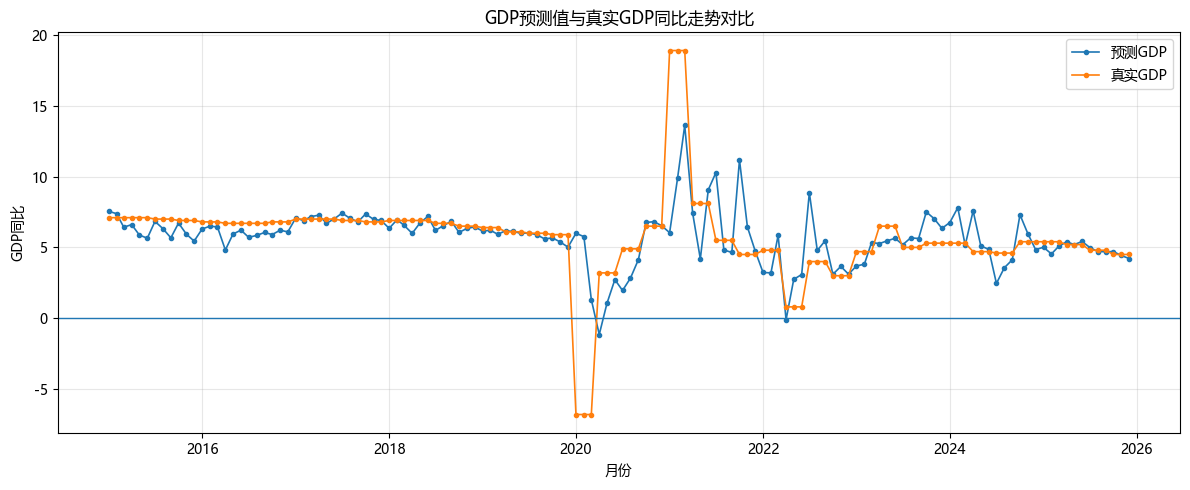

图已导出： c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\02-拟合优度\02_gdp_prediction_vs_actual.png


In [18]:
def set_chinese_font():
    candidate_fonts = [
        "Microsoft YaHei",
        "SimHei",
        "SimSun",
        "Arial Unicode MS",
        "Noto Sans CJK SC",
        "WenQuanYi Micro Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidate_fonts:
        if font in available_fonts:
            plt.rcParams["font.sans-serif"] = [font]
            break
    plt.rcParams["axes.unicode_minus"] = False


set_chinese_font()

plot_df = gdp_eval[["month", NOWCAST_COL, "actual_gdp_yoy"]].copy()
plot_df["month_ts"] = plot_df["month"].dt.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["month_ts"], plot_df[NOWCAST_COL], marker="o", markersize=3, linewidth=1.2, label="预测GDP")
plt.plot(plot_df["month_ts"], plot_df["actual_gdp_yoy"], marker="o", markersize=3, linewidth=1.2, label="真实GDP")
plt.axhline(0, linewidth=1)
plt.title("GDP预测值与真实GDP同比走势对比")
plt.xlabel("月份")
plt.ylabel("GDP同比")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIT_DIR / "02_gdp_prediction_vs_actual.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("图已导出：", fig_path)


## 3.7 导出第二、三章明细结果

这一节把拟合指标、差值分布统计、阶梯区间正确率、两种口径的方向准确率、方向混淆矩阵和评价样本明细统一导出，
后续如需复查，不在 notebook 中重复展开。

导出方法：
- 第二章导出拟合指标表和预测对比图
- 第三章导出分布统计、区间正确率、方向正确率、混淆矩阵和逐月评价明细
- 逐月明细中会保留两套口径下的 `pred_change`、`actual_change`、三分类方向和方向判定结果


In [19]:
gdp_eval.to_csv(DIRECTION_DIR / "03_gdp_prediction_evaluation_detail.csv", index=False, encoding="utf-8-sig")

print("第二、三章导出完成：")
print(" -", FIT_DIR / "02_gdp_fit_metrics.csv")
print(" -", FIT_DIR / "02_gdp_prediction_vs_actual.png")
print(" -", DIRECTION_DIR / "03_direction_signal_distribution.csv")
print(" -", DIRECTION_DIR / "03_direction_accuracy_by_abs_bucket.csv")
print(" -", DIRECTION_DIR / "03_gdp_direction_accuracy.csv")
print(" -", DIRECTION_DIR / "03_gdp_direction_confusion_matrix.csv")
print(" -", DIRECTION_DIR / "03_gdp_prediction_evaluation_detail.csv")


第二、三章导出完成：
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\02-拟合优度\02_gdp_fit_metrics.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\02-拟合优度\02_gdp_prediction_vs_actual.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\03-方向准确率\03_direction_signal_distribution.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\03-方向准确率\03_direction_accuracy_by_abs_bucket.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\03-方向准确率\03_gdp_direction_accuracy.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\03-方向准确率\03_gdp_direction_confusion_matrix.csv
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\03-方向准确率\03_gdp_prediction_evaluation_detail.csv


# 04 IC分析：IC、Rank IC 与 ICIR

这一章不再做回归暴露或横截面打分，只保留最直接的时间序列相关检验。
做法是通过 `4.0` 统一选择 GDP 比较口径，再过滤掉 `|signal| < 0.2` 的弱信号月份，
对 12 个债券收益率变量分别计算信号与下一月收益率的相关性。


## 4.0 统一分析口径选择

这一节单独提供一个配置入口，用来统一切换第四章及后续章节采用的 GDP 比较口径。

- `方案一：相较前两期真实GDP均值`：
  - Nowcasting 信号：`nowcasting_GDP - past2_actual_gdp_mean`
  - 真实 GDP 对照信号：`actual_gdp_yoy - past2_actual_gdp_mean`
- `方案二：相较上一期真实GDP`：
  - Nowcasting 信号：`nowcasting_GDP - actual_gdp_lag1`
  - 真实 GDP 对照信号：`actual_gdp_yoy - actual_gdp_lag1`

后面第四章之后的时间序列回归、横截面异质性和分层检测都会自动继承这里的选择。


In [60]:
IC_SCHEME_CHOICE = "vs_lag1_actual"
# 可选值：
# - "vs_past2_mean" -> 方案一：相较前两期真实GDP均值
# - "vs_lag1_actual" -> 方案二：相较上一期真实GDP

IC_SCHEME_CONFIG = {
    "vs_past2_mean": {
        "scheme_label": "方案一：相较前两期真实GDP均值",
        "nowcast_source_col": "ic_signal_vs_past2_mean",
        "nowcast_label": "nowcasting_GDP - past2_actual_gdp_mean",
        "actual_source_col": "actual_signal_vs_past2_mean",
        "actual_label": "actual_gdp_yoy - past2_actual_gdp_mean",
        "file_tag": "past2_mean",
        "plot_title_suffix": "相较前两期真实GDP均值",
    },
    "vs_lag1_actual": {
        "scheme_label": "方案二：相较上一期真实GDP",
        "nowcast_source_col": "ic_signal_vs_lag1_actual",
        "nowcast_label": "nowcasting_GDP - actual_gdp_lag1",
        "actual_source_col": "actual_signal_vs_lag1_actual",
        "actual_label": "actual_gdp_yoy - actual_gdp_lag1",
        "file_tag": "lag1_actual",
        "plot_title_suffix": "相较上一期真实GDP",
    },
}

if IC_SCHEME_CHOICE not in IC_SCHEME_CONFIG:
    raise ValueError(f"未知 IC 方案：{IC_SCHEME_CHOICE}。可选值：{list(IC_SCHEME_CONFIG)}")

IC_ACTIVE_CONFIG = IC_SCHEME_CONFIG[IC_SCHEME_CHOICE]
IC_ABS_THRESHOLD = 0.2
IC_ROLL_WINDOW = 36

print("当前第四章 IC 分析方案：", IC_ACTIVE_CONFIG["scheme_label"])
print("Nowcasting 信号：", IC_ACTIVE_CONFIG["nowcast_label"])
print("真实 GDP 对照信号：", IC_ACTIVE_CONFIG["actual_label"])
print("绝对值过滤阈值：", IC_ABS_THRESHOLD)
print("滚动窗口长度：", IC_ROLL_WINDOW)


当前第四章 IC 分析方案： 方案二：相较上一期真实GDP
Nowcasting 信号： nowcasting_GDP - actual_gdp_lag1
真实 GDP 对照信号： actual_gdp_yoy - actual_gdp_lag1
绝对值过滤阈值： 0.2
滚动窗口长度： 36


## 4.1 过滤弱信号样本并准备 IC 面板

这一节读取上一 cell 的方案选择，自动构造当期 Nowcasting 信号和对应的真实 GDP 对照信号，
并过滤掉绝对值小于 0.2 的月份。

计算方法：
- 当前分析口径由 `IC_SCHEME_CHOICE` 决定
- Nowcasting 主信号使用所选方案对应的 `nowcasting_GDP` 比较值
- 真实 GDP 对照信号使用同一方案下的真实 GDP 比较值
- 过滤条件：`|signal| >= IC_ABS_THRESHOLD`
- 对每个债券目标变量都使用同一套过滤后的月份样本
- 后面所有 IC、Rank IC 和滚动 IC 都基于这套过滤后的月度序列


In [61]:
required_objects = ["panel_next_1m", "IC_DIR", "IC_ACTIVE_CONFIG", "IC_ABS_THRESHOLD", "IC_ROLL_WINDOW"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"缺少对象 {obj}。请先运行前面章节。")

IC_SIGNAL_COL = "ic_signal_selected"
IC_SIGNAL_SOURCE_COL = IC_ACTIVE_CONFIG["nowcast_source_col"]
IC_SIGNAL_LABEL = IC_ACTIVE_CONFIG["nowcast_label"]
ACTUAL_SIGNAL_COL = "actual_signal_selected"
ACTUAL_SIGNAL_SOURCE_COL = IC_ACTIVE_CONFIG["actual_source_col"]
ACTUAL_SIGNAL_LABEL = IC_ACTIVE_CONFIG["actual_label"]
IC_FILE_TAG = IC_ACTIVE_CONFIG["file_tag"]
IC_PLOT_TITLE_SUFFIX = IC_ACTIVE_CONFIG["plot_title_suffix"]

ic_target_cols = [c for c in panel_next_1m.columns if c.endswith("__next_1m")]
ic_base_cols = [
    "month",
    "quarter",
    "nowcasting_GDP",
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "past2_actual_gdp_mean",
    "actual_gdp_yoy_diff",
]

ic_panel = panel_next_1m[ic_base_cols + ic_target_cols].copy()
for col in ["nowcasting_GDP", "actual_gdp_yoy", "actual_gdp_lag1", "past2_actual_gdp_mean", "actual_gdp_yoy_diff"]:
    ic_panel[col] = pd.to_numeric(ic_panel[col], errors="coerce")
for col in ic_target_cols:
    ic_panel[col] = pd.to_numeric(ic_panel[col], errors="coerce")

ic_panel["ic_signal_vs_past2_mean"] = ic_panel["nowcasting_GDP"] - ic_panel["past2_actual_gdp_mean"]
ic_panel["ic_signal_vs_lag1_actual"] = ic_panel["nowcasting_GDP"] - ic_panel["actual_gdp_lag1"]
ic_panel["actual_signal_vs_past2_mean"] = ic_panel["actual_gdp_yoy"] - ic_panel["past2_actual_gdp_mean"]
ic_panel["actual_signal_vs_lag1_actual"] = ic_panel["actual_gdp_yoy"] - ic_panel["actual_gdp_lag1"]
ic_panel[IC_SIGNAL_COL] = pd.to_numeric(ic_panel[IC_SIGNAL_SOURCE_COL], errors="coerce")
ic_panel[ACTUAL_SIGNAL_COL] = pd.to_numeric(ic_panel[ACTUAL_SIGNAL_SOURCE_COL], errors="coerce")

ic_panel = ic_panel.sort_values("month").reset_index(drop=True)
ic_panel_filtered = ic_panel.loc[ic_panel[IC_SIGNAL_COL].abs() >= IC_ABS_THRESHOLD].copy()
actual_ic_panel_filtered = ic_panel.loc[ic_panel[ACTUAL_SIGNAL_COL].abs() >= IC_ABS_THRESHOLD].copy()

print("当前 IC 方案：", IC_ACTIVE_CONFIG["scheme_label"])
print("Nowcasting 主信号源列：", IC_SIGNAL_SOURCE_COL)
print("Nowcasting 信号定义：", IC_SIGNAL_LABEL)
print("真实 GDP 对照信号源列：", ACTUAL_SIGNAL_SOURCE_COL)
print("真实 GDP 对照定义：", ACTUAL_SIGNAL_LABEL)
print("IC 过滤阈值：", IC_ABS_THRESHOLD)
print("Nowcasting 过滤前月份数：", len(ic_panel))
print("Nowcasting 过滤后月份数：", len(ic_panel_filtered))
print("真实 GDP 过滤后月份数：", len(actual_ic_panel_filtered))
print("债券目标变量数量：", len(ic_target_cols))


当前 IC 方案： 方案二：相较上一期真实GDP
Nowcasting 主信号源列： ic_signal_vs_lag1_actual
Nowcasting 信号定义： nowcasting_GDP - actual_gdp_lag1
真实 GDP 对照信号源列： actual_signal_vs_lag1_actual
真实 GDP 对照定义： actual_gdp_yoy - actual_gdp_lag1
IC 过滤阈值： 0.2
Nowcasting 过滤前月份数： 132
Nowcasting 过滤后月份数： 113
真实 GDP 过滤后月份数： 78
债券目标变量数量： 12


## 4.2 计算 12 个债券变量的全样本 IC、Rank IC 与 ICIR

这一节对 12 个债券变量分别计算过滤后全样本的 Pearson 相关和 Spearman 相关，并同时报告显著性检验结果。
由于这里研究的备择假设是“GDP 变化越强，债券下月收益越弱”，因此显著性检验改为负向单边检验：`H0: IC >= 0`，`H1: IC < 0`。
由于这里不再有逐月横截面 IC 序列，`ICIR` 改为基于后面 36 个月滚动 IC 序列的 `mean / std`。

计算方法：
- `IC = corr((所选 nowcasting 信号)_t, bond_ret_{t+1})`
- `Rank IC = spearman_corr((所选 nowcasting 信号)_t, bond_ret_{t+1})`
- `IC p-value` 与 `Rank IC p-value` 均为负向单边检验结果
- `ICIR_36m = mean(rolling_36m_ic) / std(rolling_36m_ic)`
- `Rank_ICIR_36m = mean(rolling_36m_rank_ic) / std(rolling_36m_rank_ic)`


In [62]:
def to_left_tail_p_value(corr_val: float, two_sided_p_value: float):
    if pd.isna(corr_val) or pd.isna(two_sided_p_value):
        return np.nan
    if corr_val < 0:
        return two_sided_p_value / 2
    return 1 - two_sided_p_value / 2


def calc_corr_stats(df: pd.DataFrame, signal_col: str, target_col: str, method: str):
    tmp = df[[signal_col, target_col]].dropna().copy()
    n_obs = len(tmp)
    if n_obs < 3 or tmp[signal_col].nunique() < 2 or tmp[target_col].nunique() < 2:
        return np.nan, np.nan, n_obs

    if method == "pearson":
        corr_val, p_value_two_sided = stats.pearsonr(tmp[signal_col], tmp[target_col])
    elif method == "spearman":
        corr_val, p_value_two_sided = stats.spearmanr(tmp[signal_col], tmp[target_col])
    else:
        raise ValueError(f"Unsupported method: {method}")

    p_value_left_tail = to_left_tail_p_value(corr_val, p_value_two_sided)
    return corr_val, p_value_left_tail, n_obs


def build_rolling_corr_table(df: pd.DataFrame, signal_col: str, target_col: str, window: int) -> pd.DataFrame:
    tmp = df[["month", signal_col, target_col]].dropna().sort_values("month").reset_index(drop=True).copy()
    rows = []
    if tmp.empty:
        return pd.DataFrame(columns=[
            "target_clean", "month", "window_n",
            "rolling_ic", "rolling_ic_p_value", "rolling_ic_sig_5pct",
            "rolling_rank_ic", "rolling_rank_ic_p_value", "rolling_rank_ic_sig_5pct",
        ])

    month_endpoints = sorted(tmp["month"].unique())
    for month_end in month_endpoints:
        month_start = month_end - (window - 1)
        window_df = tmp[(tmp["month"] >= month_start) & (tmp["month"] <= month_end)].copy()

        ic_val, ic_p_value, n_obs = calc_corr_stats(window_df, signal_col, target_col, method="pearson")
        rank_ic_val, rank_ic_p_value, _ = calc_corr_stats(window_df, signal_col, target_col, method="spearman")

        rows.append({
            "target_clean": target_col.replace("__next_1m", ""),
            "month": month_end,
            "window_n": n_obs,
            "rolling_ic": ic_val,
            "rolling_ic_p_value": ic_p_value,
            "rolling_ic_sig_5pct": bool(pd.notna(ic_p_value) and ic_p_value < 0.05),
            "rolling_rank_ic": rank_ic_val,
            "rolling_rank_ic_p_value": rank_ic_p_value,
            "rolling_rank_ic_sig_5pct": bool(pd.notna(rank_ic_p_value) and rank_ic_p_value < 0.05),
        })

    return pd.DataFrame(rows)


ic_summary_rows = []
rolling_tables = []

for target_col in ic_target_cols:
    target_clean = target_col.replace("__next_1m", "")
    ic_val, ic_p_value, n_obs = calc_corr_stats(ic_panel_filtered, IC_SIGNAL_COL, target_col, method="pearson")
    rank_ic_val, rank_ic_p_value, _ = calc_corr_stats(ic_panel_filtered, IC_SIGNAL_COL, target_col, method="spearman")

    rolling_table = build_rolling_corr_table(ic_panel_filtered, IC_SIGNAL_COL, target_col, window=IC_ROLL_WINDOW)
    rolling_tables.append(rolling_table.assign(signal_type=IC_SIGNAL_SOURCE_COL))

    rolling_ic_nonnull = rolling_table["rolling_ic"].dropna()
    rolling_rank_ic_nonnull = rolling_table["rolling_rank_ic"].dropna()

    ic_summary_rows.append({
        "signal_col": IC_SIGNAL_SOURCE_COL,
        "signal_label": IC_SIGNAL_LABEL,
        "target_clean": target_clean,
        "n_obs": n_obs,
        "ic": ic_val,
        "ic_p_value": ic_p_value,
        "rank_ic": rank_ic_val,
        "rank_ic_p_value": rank_ic_p_value,
        "icir_36m": rolling_ic_nonnull.mean() / rolling_ic_nonnull.std(ddof=1) if len(rolling_ic_nonnull) > 1 and rolling_ic_nonnull.std(ddof=1) > 0 else np.nan,
        "rank_icir_36m": rolling_rank_ic_nonnull.mean() / rolling_rank_ic_nonnull.std(ddof=1) if len(rolling_rank_ic_nonnull) > 1 and rolling_rank_ic_nonnull.std(ddof=1) > 0 else np.nan,
        "rolling_ic_sig_ratio": rolling_table["rolling_ic_sig_5pct"].mean() if not rolling_table.empty else np.nan,
        "rolling_rank_ic_sig_ratio": rolling_table["rolling_rank_ic_sig_5pct"].mean() if not rolling_table.empty else np.nan,
    })

ic_summary_by_bond = pd.DataFrame(ic_summary_rows).sort_values("target_clean").reset_index(drop=True)
rolling_ic_by_bond = pd.concat(rolling_tables, ignore_index=True) if rolling_tables else pd.DataFrame()
if not rolling_ic_by_bond.empty:
    rolling_ic_by_bond = rolling_ic_by_bond.sort_values(["target_clean", "month"]).reset_index(drop=True)

ic_summary_path = IC_DIR / f"04_nowcasting_{IC_FILE_TAG}_ic_summary_by_bond.csv"
rolling_ic_path = IC_DIR / f"04_nowcasting_{IC_FILE_TAG}_rolling_36m_ic_by_bond.csv"
ic_summary_by_bond.to_csv(ic_summary_path, index=False, encoding="utf-8-sig")
rolling_ic_by_bond.to_csv(rolling_ic_path, index=False, encoding="utf-8-sig")

print(f"当前 IC 方案: {IC_ACTIVE_CONFIG['scheme_label']}")
print(f"Main IC signal: {IC_SIGNAL_SOURCE_COL} | {IC_SIGNAL_LABEL}")
print(f"Abs threshold: {IC_ABS_THRESHOLD}")
print(f"Filtered observations: {len(ic_panel_filtered)}")
print("\nFull-sample IC summary (one-sided p-value):")
print(ic_summary_by_bond.round(4).to_string(index=False))
print(f"\nExported: {ic_summary_path}")
print(f"Exported: {rolling_ic_path}")


当前 IC 方案: 方案二：相较上一期真实GDP
Main IC signal: ic_signal_vs_lag1_actual | nowcasting_GDP - actual_gdp_lag1
Abs threshold: 0.2
Filtered observations: 113

Full-sample IC summary (one-sided p-value):
              signal_col                     signal_label     target_clean  n_obs      ic  ic_p_value  rank_ic  rank_ic_p_value  icir_36m  rank_icir_36m  rolling_ic_sig_ratio  rolling_rank_ic_sig_ratio
ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合全价(3-5年)指数    113 -0.1129      0.1170  -0.0203           0.4157   -0.6523        -0.3795                0.1947                     0.0885
ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合全价(5-7年)指数    113 -0.0896      0.1725  -0.0133           0.4442   -0.4022        -0.1848                0.0442                     0.0796
ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合净价(3-5年)指数    113 -0.1129      0.1170  -0.0220           0.4083   -0.6808        -0.4485                0.2212                     0.0619


## 4.3 计算 3 年自然月滚动窗口 IC

这一节继续对 12 个债券变量分别计算 3 年自然月滚动窗口 IC 和滚动窗口 Rank IC。
这里不再要求窗口内必须凑满 36 个有效样本，而是固定看“最近 36 个自然月”这段时间内的可用样本，并对每个窗口做负向单边显著性检验：`H0: IC >= 0`，`H1: IC < 0`。

计算方法：
- 对每个债券变量，以每个月为窗口终点，回看最近 36 个自然月
- 在这 36 个自然月内，取通过阈值过滤且有债券收益数据的样本点
- 只要窗口内可用样本数不少于 3，且信号与收益都不是常数，就计算
- 对每个窗口同时计算 `rolling_ic`、`rolling_ic_p_value`、`rolling_rank_ic`、`rolling_rank_ic_p_value`
- 上述 `p-value` 均为负向单边检验结果，因此只有“显著为负”的窗口会被记为显著
- 导出完整滚动序列表，并在 notebook 中只打印每个变量最近一个窗口结果


In [63]:
print("最近一个 36 个月滚动窗口结果：")
if rolling_ic_by_bond.empty:
    print("过滤后样本不足 36 个月，当前无法形成滚动 IC 窗口。")
else:
    latest_rolling_ic = (
        rolling_ic_by_bond
        .sort_values(["target_clean", "month"])
        .groupby("target_clean", as_index=False)
        .tail(1)
        [[
            "target_clean", "month", "window_n",
            "rolling_ic", "rolling_ic_p_value", "rolling_ic_sig_5pct",
            "rolling_rank_ic", "rolling_rank_ic_p_value", "rolling_rank_ic_sig_5pct",
        ]]
        .sort_values("target_clean")
        .reset_index(drop=True)
    )
    print(latest_rolling_ic.round(4).to_string(index=False))


最近一个 36 个月滚动窗口结果：
    target_clean   month  window_n  rolling_ic  rolling_ic_p_value  rolling_ic_sig_5pct  rolling_rank_ic  rolling_rank_ic_p_value  rolling_rank_ic_sig_5pct
中债-新综合全价(3-5年)指数 2025-12        31      0.4415              0.9935                False           0.3117                   0.9561                     False
中债-新综合全价(5-7年)指数 2025-12        31      0.4803              0.9969                False           0.4004                   0.9872                     False
中债-新综合净价(3-5年)指数 2025-12        31      0.4580              0.9952                False           0.3411                   0.9698                     False
中债-新综合净价(5-7年)指数 2025-12        31      0.4939              0.9976                False           0.4383                   0.9932                     False
中债-新综合财富(3-5年)指数 2025-12        31      0.4580              0.9952                False           0.3411                   0.9698                     False
中债-新综合财富(5-7年)指数 2025-12        31      0.4938

## 4.4 绘制 12 个债券变量的 3 年自然月滚动 IC 序列

这一节把 12 个债券变量各自的 3 年自然月滚动 IC 序列分别画成一张图，
只画 `rolling_ic`，并把负向单边检验下 `rolling_ic_p_value < 0.05` 的窗口标注成红点，
便于直接看当前所选 Nowcasting 口径的相关方向是否稳定，以及哪些阶段的滚动 IC 显著为负。


In [64]:
def set_chinese_font_local():
    candidate_fonts = [
        "Microsoft YaHei",
        "SimHei",
        "SimSun",
        "Arial Unicode MS",
        "Noto Sans CJK SC",
        "WenQuanYi Micro Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    for font in candidate_fonts:
        if font in available_fonts:
            plt.rcParams["font.sans-serif"] = [font]
            break
    plt.rcParams["axes.unicode_minus"] = False


def make_safe_filename(text: str) -> str:
    replace_map = {
        "/": "_",
        chr(92): "_",
        " ": "",
        "(": "_",
        ")": "_",
        "-": "_",
    }
    out = text
    for old, new in replace_map.items():
        out = out.replace(old, new)
    return out


set_chinese_font_local()

print("滚动 IC 图片导出：")
if rolling_ic_by_bond.empty:
    print("过滤后样本不足 36 个月，当前无法绘制滚动 IC 图。")
else:
    for target_clean, df_target in rolling_ic_by_bond.groupby("target_clean"):
        plot_df = df_target.sort_values("month").copy()
        plot_df["month_ts"] = plot_df["month"].dt.to_timestamp()
        sig_df = plot_df.loc[plot_df["rolling_ic_sig_5pct"].fillna(False)].copy()

        plt.figure(figsize=(10, 4.5))
        plt.plot(plot_df["month_ts"], plot_df["rolling_ic"], linewidth=1.5, label="Rolling IC")
        if not sig_df.empty:
            plt.scatter(
                sig_df["month_ts"],
                sig_df["rolling_ic"],
                color="red",
                s=24,
                zorder=3,
                label="p < 0.05",
            )
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"{target_clean}：{IC_PLOT_TITLE_SUFFIX}的36个月滚动IC")
        plt.xlabel("月份")
        plt.ylabel("Rolling IC")
        plt.grid(True, alpha=0.3)
        if not sig_df.empty:
            plt.legend(frameon=False)
        plt.tight_layout()

        fig_path = IC_DIR / f"04_nowcasting_{IC_FILE_TAG}_rolling_ic_{make_safe_filename(target_clean)}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(" -", fig_path)


滚动 IC 图片导出：
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合全价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合全价_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合净价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合净价_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合财富_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_新综合财富_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowcasting_lag1_actual_rolling_ic_中债_综合全价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_nowc

## 4.5 真实 GDP 变化与下月债券收益率关系

这一节把真实 GDP 变化切到与前面所选方案一致的比较口径，
用它和下月债券收益率做对照，判断债券收益率对“真实增长动能”本身是否更敏感。
显著性检验同样使用负向单边检验：`H0: IC >= 0`，`H1: IC < 0`。

计算方法：
- 真实 GDP 对照信号使用 `IC_SCHEME_CHOICE` 对应的真实 GDP 比较值
- 继续沿用过滤条件：`|actual signal| >= IC_ABS_THRESHOLD`
- 对 12 个债券变量分别计算 `IC = corr((所选真实 GDP 对照信号)_t, bond_ret_{t+1})`
- 同时计算 `Rank IC = spearman_corr((所选真实 GDP 对照信号)_t, bond_ret_{t+1})`
- 对应 `p-value` 均按负向单边检验计算
- 再计算 36 个月滚动 IC，并导出逐债券图


In [65]:
actual_ic_rows = []
actual_rolling_tables = []

for target_col in ic_target_cols:
    target_clean = target_col.replace("__next_1m", "")
    ic_val, ic_p_value, n_obs = calc_corr_stats(actual_ic_panel_filtered, ACTUAL_SIGNAL_COL, target_col, method="pearson")
    rank_ic_val, rank_ic_p_value, _ = calc_corr_stats(actual_ic_panel_filtered, ACTUAL_SIGNAL_COL, target_col, method="spearman")

    rolling_table = build_rolling_corr_table(actual_ic_panel_filtered, ACTUAL_SIGNAL_COL, target_col, window=IC_ROLL_WINDOW)
    actual_rolling_tables.append(rolling_table.assign(signal_type=ACTUAL_SIGNAL_SOURCE_COL))

    rolling_ic_nonnull = rolling_table["rolling_ic"].dropna()
    rolling_rank_ic_nonnull = rolling_table["rolling_rank_ic"].dropna()

    actual_ic_rows.append({
        "actual_signal_col": ACTUAL_SIGNAL_SOURCE_COL,
        "actual_signal_label": ACTUAL_SIGNAL_LABEL,
        "target_clean": target_clean,
        "n_obs": n_obs,
        "ic": ic_val,
        "ic_p_value": ic_p_value,
        "rank_ic": rank_ic_val,
        "rank_ic_p_value": rank_ic_p_value,
        "icir_36m": rolling_ic_nonnull.mean() / rolling_ic_nonnull.std(ddof=1) if len(rolling_ic_nonnull) > 1 and rolling_ic_nonnull.std(ddof=1) > 0 else np.nan,
        "rank_icir_36m": rolling_rank_ic_nonnull.mean() / rolling_rank_ic_nonnull.std(ddof=1) if len(rolling_rank_ic_nonnull) > 1 and rolling_rank_ic_nonnull.std(ddof=1) > 0 else np.nan,
        "rolling_ic_sig_ratio": rolling_table["rolling_ic_sig_5pct"].mean() if not rolling_table.empty else np.nan,
        "rolling_rank_ic_sig_ratio": rolling_table["rolling_rank_ic_sig_5pct"].mean() if not rolling_table.empty else np.nan,
    })

actual_ic_detail = pd.DataFrame(actual_ic_rows).sort_values("target_clean").reset_index(drop=True)
actual_rolling_ic_by_bond = pd.concat(actual_rolling_tables, ignore_index=True) if actual_rolling_tables else pd.DataFrame()
if not actual_rolling_ic_by_bond.empty:
    actual_rolling_ic_by_bond = actual_rolling_ic_by_bond.sort_values(["target_clean", "month"]).reset_index(drop=True)

actual_ic_detail_path = IC_DIR / f"04_actual_{IC_FILE_TAG}_ic_detail.csv"
actual_rolling_ic_path = IC_DIR / f"04_actual_{IC_FILE_TAG}_rolling_36m_ic_by_bond.csv"
actual_ic_detail.to_csv(actual_ic_detail_path, index=False, encoding="utf-8-sig")
actual_rolling_ic_by_bond.to_csv(actual_rolling_ic_path, index=False, encoding="utf-8-sig")

print(f"当前 IC 方案: {IC_ACTIVE_CONFIG['scheme_label']}")
print(f"Actual GDP comparison signal: {ACTUAL_SIGNAL_SOURCE_COL} | {ACTUAL_SIGNAL_LABEL}")
print(f"Abs threshold: {IC_ABS_THRESHOLD}")
print(f"Filtered observations: {len(actual_ic_panel_filtered)}")
print("\nActual-GDP IC summary (one-sided p-value):")
print(actual_ic_detail.round(4).to_string(index=False))
print(f"\nExported: {actual_ic_detail_path}")
print(f"Exported: {actual_rolling_ic_path}")


当前 IC 方案: 方案二：相较上一期真实GDP
Actual GDP comparison signal: actual_signal_vs_lag1_actual | actual_gdp_yoy - actual_gdp_lag1
Abs threshold: 0.2
Filtered observations: 78

Actual-GDP IC summary (one-sided p-value):
           actual_signal_col              actual_signal_label     target_clean  n_obs      ic  ic_p_value  rank_ic  rank_ic_p_value  icir_36m  rank_icir_36m  rolling_ic_sig_ratio  rolling_rank_ic_sig_ratio
actual_signal_vs_lag1_actual actual_gdp_yoy - actual_gdp_lag1 中债-新综合全价(3-5年)指数     78 -0.2855      0.0056  -0.1668           0.0722   -1.2636        -1.1847                0.5641                     0.3974
actual_signal_vs_lag1_actual actual_gdp_yoy - actual_gdp_lag1 中债-新综合全价(5-7年)指数     78 -0.2632      0.0099  -0.1474           0.0989   -1.1742        -0.9375                0.5385                     0.5128
actual_signal_vs_lag1_actual actual_gdp_yoy - actual_gdp_lag1 中债-新综合净价(3-5年)指数     78 -0.2850      0.0057  -0.1524           0.0914   -1.2218        -1.0694                0.

## 4.6 绘制真实 GDP 对照信号的 3 年自然月滚动 IC 序列

这一节把真实 GDP 对照信号在当前所选口径下的滚动 IC 也分别画成 12 张图，
并把负向单边检验下 `rolling_ic_p_value < 0.05` 的窗口标注成红点，方便直接和 nowcasting 版本对照。


In [66]:
print("真实 GDP 滚动 IC 图片导出：")
if actual_rolling_ic_by_bond.empty:
    print("过滤后样本不足 36 个月，当前无法绘制真实 GDP 滚动 IC 图。")
else:
    for target_clean, df_target in actual_rolling_ic_by_bond.groupby("target_clean"):
        plot_df = df_target.sort_values("month").copy()
        plot_df["month_ts"] = plot_df["month"].dt.to_timestamp()
        sig_df = plot_df.loc[plot_df["rolling_ic_sig_5pct"].fillna(False)].copy()

        plt.figure(figsize=(10, 4.5))
        plt.plot(plot_df["month_ts"], plot_df["rolling_ic"], linewidth=1.5, label="Rolling IC")
        if not sig_df.empty:
            plt.scatter(
                sig_df["month_ts"],
                sig_df["rolling_ic"],
                color="red",
                s=24,
                zorder=3,
                label="p < 0.05",
            )
        plt.axhline(0, color="black", linewidth=1)
        plt.title(f"{target_clean}：真实GDP{IC_PLOT_TITLE_SUFFIX}的36个月滚动IC")
        plt.xlabel("月份")
        plt.ylabel("Rolling IC")
        plt.grid(True, alpha=0.3)
        if not sig_df.empty:
            plt.legend(frameon=False)
        plt.tight_layout()

        fig_path = IC_DIR / f"04_actual_{IC_FILE_TAG}_rolling_ic_{make_safe_filename(target_clean)}.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.close()
        print(" -", fig_path)


真实 GDP 滚动 IC 图片导出：
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合全价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合全价_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合净价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合净价_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合财富_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_新综合财富_5_7年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rolling_ic_中债_综合全价_3_5年_指数.png
 - c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\04-IC分析\04_actual_lag1_actual_rollin

# 05 时间序列回归：GDP信号解释下一个月债券收益率变化

这一章在 IC 之后进一步检验 GDP 信号的经济量级和统计显著性。
这里会自动继承 `4.0` 中的口径选择，对同一方案下的 nowcasting 信号和真实 GDP 对照信号分别做回归。
notebook 里只打印每个债券指数的核心回归结果和控制变量可用性，详细结果导出到 csv。


## 5.1 构造回归长表与控制变量配置

这一节把宽表债券面板转成长表，并为每个债券指数补上期限桶和指数类型标签。
回归会自动继承 `4.0` 的方案选择，同时对该方案下的两类信号各跑一遍：
- nowcasting GDP 信号
- 真实 GDP 对照信号

这一章现在只保留一套回归规格：
- `Model3_gdp_plus_macro_liquidity`：GDP 信号 + 当前能拿到且不缺失的宏观与资金面控制


In [67]:
required_objects = ["panel_next_1m_with_macro", "IC_ACTIVE_CONFIG", "IC_SCHEME_CHOICE"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"缺少对象 {obj}。请先运行 4.0 口径选择 cell。")


def parse_duration_bucket(name: str) -> str:
    if "3-5年" in name:
        return "3-5年"
    if "5-7年" in name:
        return "5-7年"
    return "其他"


def parse_index_type(name: str) -> str:
    if "财富" in name:
        return "财富"
    if "净价" in name:
        return "净价"
    if "全价" in name:
        return "全价"
    return "其他"


def parse_series_family(name: str) -> str:
    if "新综合" in name:
        return "新综合"
    if "综合" in name:
        return "综合"
    return "其他"


REG_FILE_TAG = IC_ACTIVE_CONFIG["file_tag"]
REG_SCHEME_LABEL = IC_ACTIVE_CONFIG["scheme_label"]
REG_NOWCAST_SIGNAL_COL = IC_ACTIVE_CONFIG["nowcast_source_col"]
REG_NOWCAST_SIGNAL_LABEL = IC_ACTIVE_CONFIG["nowcast_label"]
REG_ACTUAL_SIGNAL_COL = IC_ACTIVE_CONFIG["actual_source_col"]
REG_ACTUAL_SIGNAL_LABEL = IC_ACTIVE_CONFIG["actual_label"]

reg_panel = panel_next_1m_with_macro.copy()
for col in ["nowcasting_GDP", "actual_gdp_yoy", "actual_gdp_lag1", "past2_actual_gdp_mean"]:
    reg_panel[col] = pd.to_numeric(reg_panel[col], errors="coerce")

reg_panel["ic_signal_vs_past2_mean"] = reg_panel["nowcasting_GDP"] - reg_panel["past2_actual_gdp_mean"]
reg_panel["ic_signal_vs_lag1_actual"] = reg_panel["nowcasting_GDP"] - reg_panel["actual_gdp_lag1"]
reg_panel["actual_signal_vs_past2_mean"] = reg_panel["actual_gdp_yoy"] - reg_panel["past2_actual_gdp_mean"]
reg_panel["actual_signal_vs_lag1_actual"] = reg_panel["actual_gdp_yoy"] - reg_panel["actual_gdp_lag1"]

reg_target_cols = [c for c in reg_panel.columns if c.endswith("__next_1m")]

id_cols = [
    "month",
    "quarter",
    NOWCAST_COL,
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "actual_gdp_lag2",
    "past2_actual_gdp_mean",
    "gdp_signal_direction",
    "gdp_signal_abs",
    "gdp_gap_vs_lag2_avg",
    "nowcasting_gdp_diff",
    "ic_signal_vs_past2_mean",
    "ic_signal_vs_lag1_actual",
    "actual_signal_vs_past2_mean",
    "actual_signal_vs_lag1_actual",
]
control_pool = [c for c in reg_panel.columns if c not in id_cols + reg_target_cols]

long_reg = reg_panel[id_cols + control_pool + reg_target_cols].melt(
    id_vars=id_cols + control_pool,
    value_vars=reg_target_cols,
    var_name="target",
    value_name="bond_ret_next_1m",
)
long_reg["target_clean"] = long_reg["target"].str.replace("__next_1m", "", regex=False)
long_reg["duration_bucket"] = long_reg["target_clean"].apply(parse_duration_bucket)
long_reg["index_type"] = long_reg["target_clean"].apply(parse_index_type)
long_reg["series_family"] = long_reg["target_clean"].apply(parse_series_family)

inflation_controls = [c for c in ["中国:CPI:当月同比", "中国:PPI:当月同比"] if c in long_reg.columns]
rate_controls_for_reg = [
    c
    for c in [
        "DR007_月均_较上月变动",
        "逆回购7天_月末_较上月变动",
        "MLF1Y_月末_较上月变动",
        "LPR1Y_月末_较上月变动",
        "资金利差_DR007减逆回购_较上月变动",
        "资金利差_DR007减MLF_较上月变动",
    ]
    if c in long_reg.columns
]
macro_activity_candidates = [
    c
    for c in [
        "中国:制造业PMI:一阶差分",
        "中国:非制造业PMI:服务业:一阶差分",
        "中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分)",
        "中国:全社会用电量:当月同比",
        "中国:社会消费品零售总额:当月同比(1-2月合并)",
        "中国:固定资产投资完成额:当月同比",
        "中国:城镇调查失业率:一阶差分",
    ]
    if c in long_reg.columns
]
macro_activity_complete_controls = [c for c in macro_activity_candidates if long_reg[c].notna().all()]
macro_activity_dropped_controls = [c for c in macro_activity_candidates if c not in macro_activity_complete_controls]
broad_controls = inflation_controls + macro_activity_complete_controls + rate_controls_for_reg

regression_signal_specs = {
    "nowcasting_gdp_signal": {
        "signal_col": REG_NOWCAST_SIGNAL_COL,
        "signal_label": REG_NOWCAST_SIGNAL_LABEL,
    },
    "actual_gdp_signal": {
        "signal_col": REG_ACTUAL_SIGNAL_COL,
        "signal_label": REG_ACTUAL_SIGNAL_LABEL,
    },
}

missing_control_blocks = {
    "资金面": "已并入利率相关数据月频控制" if rate_controls_for_reg else "当前文件中仍缺失",
    "海外利率": "当前文件中未直接提供",
}

print("当前回归方案：", REG_SCHEME_LABEL)
print("回归长表样本量：", len(long_reg))
print("回归信号：", {k: v["signal_label"] for k, v in regression_signal_specs.items()})
print("可用通胀控制：", inflation_controls)
print("可用资金面控制：", rate_controls_for_reg)
print("保留的宏观活动控制：", macro_activity_complete_controls)
print("因缺失被排除的宏观活动控制：", macro_activity_dropped_controls)
print("Model3 使用的控制变量数量：", len(broad_controls))
print("当前缺失的控制模块：", missing_control_blocks)


当前回归方案： 方案二：相较上一期真实GDP
回归长表样本量： 1584
回归信号： {'nowcasting_gdp_signal': 'nowcasting_GDP - actual_gdp_lag1', 'actual_gdp_signal': 'actual_gdp_yoy - actual_gdp_lag1'}
可用通胀控制： ['中国:CPI:当月同比', '中国:PPI:当月同比']
可用资金面控制： ['DR007_月均_较上月变动', '逆回购7天_月末_较上月变动', 'MLF1Y_月末_较上月变动', 'LPR1Y_月末_较上月变动', '资金利差_DR007减逆回购_较上月变动', '资金利差_DR007减MLF_较上月变动']
保留的宏观活动控制： ['中国:制造业PMI:一阶差分', '中国:非制造业PMI:服务业:一阶差分', '中国:工业增加值:规模以上工业企业:当月同比(1-2月拆分)']
因缺失被排除的宏观活动控制： ['中国:全社会用电量:当月同比', '中国:社会消费品零售总额:当月同比(1-2月合并)', '中国:固定资产投资完成额:当月同比', '中国:城镇调查失业率:一阶差分']
Model3 使用的控制变量数量： 11
当前缺失的控制模块： {'资金面': '已并入利率相关数据月频控制', '海外利率': '当前文件中未直接提供'}


## 5.2 回归函数与逐债券回归

这一节对每个债券指数分别做 OLS，并使用 HAC(3) 标准误。
同一套模型会分别对 `4.0` 当前方案下的 nowcasting GDP 信号和真实 GDP 对照信号各跑一遍。
这里仅保留 `Model3_gdp_plus_macro_liquidity`，重点看 GDP 信号系数 `beta`、t 值、p 值和调整后 `R²`。


In [68]:
def run_hac_ols(df: pd.DataFrame, y_col: str, x_cols: list, signal_col: str, model_name: str):
    tmp = df[[y_col] + x_cols].dropna().copy()
    if len(tmp) < max(24, len(x_cols) + 5):
        return None

    y = tmp[y_col].astype(float)
    X = sm.add_constant(tmp[x_cols].astype(float), has_constant="add")
    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 3})

    return {
        "model_name": model_name,
        "signal_col": signal_col,
        "n_obs": int(model.nobs),
        "beta": model.params.get(signal_col, np.nan),
        "t_stat": model.tvalues.get(signal_col, np.nan),
        "p_value": model.pvalues.get(signal_col, np.nan),
        "adj_r2": model.rsquared_adj,
    }


MODEL3_NAME = "Model3_gdp_plus_macro_liquidity"

regression_rows = []
for target_name, df_target in long_reg.groupby("target_clean"):
    meta = {
        "target_clean": target_name,
        "duration_bucket": df_target["duration_bucket"].iloc[0],
        "index_type": df_target["index_type"].iloc[0],
        "series_family": df_target["series_family"].iloc[0],
    }
    for signal_name, signal_spec in regression_signal_specs.items():
        signal_col = signal_spec["signal_col"]
        signal_label = signal_spec["signal_label"]
        x_cols = [signal_col] + broad_controls
        result = run_hac_ols(df_target, "bond_ret_next_1m", x_cols, signal_col, MODEL3_NAME)
        if result is None:
            continue
        regression_rows.append({
            **meta,
            "scheme_choice": IC_SCHEME_CHOICE,
            "scheme_label": REG_SCHEME_LABEL,
            "signal_name": signal_name,
            "signal_label": signal_label,
            **result,
        })

regression_results = pd.DataFrame(
    regression_rows,
    columns=[
        "target_clean",
        "duration_bucket",
        "index_type",
        "series_family",
        "scheme_choice",
        "scheme_label",
        "signal_name",
        "signal_label",
        "model_name",
        "signal_col",
        "n_obs",
        "beta",
        "t_stat",
        "p_value",
        "adj_r2",
    ],
)
regression_by_bond_path = REG_DIR / f"05_ts_regression_results_by_bond_{REG_FILE_TAG}.csv"
regression_results.to_csv(regression_by_bond_path, index=False, encoding="utf-8-sig")

print("逐债券回归结果摘要：")
if regression_results.empty:
    print("当前样本下没有满足最小样本要求的回归结果。")
else:
    print(regression_results.round(4).to_string(index=False))
print("\n导出：", regression_by_bond_path)


逐债券回归结果摘要：
    target_clean duration_bucket index_type series_family  scheme_choice   scheme_label           signal_name                     signal_label                      model_name                   signal_col  n_obs    beta  t_stat  p_value  adj_r2
中债-新综合全价(3-5年)指数            3-5年         全价           新综合 vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal nowcasting_GDP - actual_gdp_lag1 Model3_gdp_plus_macro_liquidity     ic_signal_vs_lag1_actual    118 -0.0002 -1.5642   0.1178  0.0689
中债-新综合全价(3-5年)指数            3-5年         全价           新综合 vs_lag1_actual 方案二：相较上一期真实GDP     actual_gdp_signal actual_gdp_yoy - actual_gdp_lag1 Model3_gdp_plus_macro_liquidity actual_signal_vs_lag1_actual    118 -0.0003 -2.3142   0.0207  0.0969
中债-新综合全价(5-7年)指数            5-7年         全价           新综合 vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal nowcasting_GDP - actual_gdp_lag1 Model3_gdp_plus_macro_liquidity     ic_signal_vs_lag1_actual    118 -0.0003 -1.6460   0.0998  0.1027
中债-新综合全价(5-7年

## 5.4 90个月滚动窗口回归

这一节在 `Model3_gdp_plus_macro_liquidity` 的同一套设定下，
对每个债券指数分别做 90 个月自然月滚动窗口回归，并继续使用 HAC(3) 标准误。
输出逐窗口回归结果，并打印每个债券在最新窗口下的 `beta`、`t_stat`、`p_value` 和 `adj_r2`。


In [69]:
ROLLING_REG_WINDOW = 90
ROLLING_REG_MODEL_NAME = f"{MODEL3_NAME}_rolling_{ROLLING_REG_WINDOW}m"

def build_rolling_hac_ols_table(df: pd.DataFrame, y_col: str, x_cols: list, signal_col: str, model_name: str, window: int) -> pd.DataFrame:
    tmp = df[["month", y_col] + x_cols].copy()
    month_endpoints = sorted(tmp["month"].dropna().unique())
    rows = []

    for month_end in month_endpoints:
        month_start = month_end - (window - 1)
        window_df = tmp[(tmp["month"] >= month_start) & (tmp["month"] <= month_end)].copy()
        result = run_hac_ols(window_df, y_col, x_cols, signal_col, model_name)
        if result is None:
            continue
        rows.append({
            "month": month_end,
            "window_months": window,
            **result,
        })

    return pd.DataFrame(rows)


rolling_regression_rows = []
for target_name, df_target in long_reg.groupby("target_clean"):
    meta = {
        "target_clean": target_name,
        "duration_bucket": df_target["duration_bucket"].iloc[0],
        "index_type": df_target["index_type"].iloc[0],
        "series_family": df_target["series_family"].iloc[0],
    }
    for signal_name, signal_spec in regression_signal_specs.items():
        signal_col = signal_spec["signal_col"]
        signal_label = signal_spec["signal_label"]
        x_cols = [signal_col] + broad_controls
        rolling_table = build_rolling_hac_ols_table(
            df_target,
            "bond_ret_next_1m",
            x_cols,
            signal_col,
            ROLLING_REG_MODEL_NAME,
            window=ROLLING_REG_WINDOW,
        )
        if rolling_table.empty:
            continue
        rolling_table = rolling_table.assign(
            scheme_choice=IC_SCHEME_CHOICE,
            scheme_label=REG_SCHEME_LABEL,
            signal_name=signal_name,
            signal_label=signal_label,
            **meta,
        )
        rolling_regression_rows.append(rolling_table)

rolling_regression_results = pd.concat(rolling_regression_rows, ignore_index=True) if rolling_regression_rows else pd.DataFrame(columns=[
    "target_clean", "duration_bucket", "index_type", "series_family",
    "scheme_choice", "scheme_label", "signal_name", "signal_label",
    "month", "window_months", "model_name", "signal_col", "n_obs",
    "beta", "t_stat", "p_value", "adj_r2",
])
if not rolling_regression_results.empty:
    rolling_regression_results = rolling_regression_results[[
        "target_clean", "duration_bucket", "index_type", "series_family",
        "scheme_choice", "scheme_label", "signal_name", "signal_label",
        "month", "window_months", "model_name", "signal_col", "n_obs",
        "beta", "t_stat", "p_value", "adj_r2",
    ]].sort_values(["target_clean", "signal_name", "month"]).reset_index(drop=True)

rolling_regression_path = REG_DIR / f"05_ts_rolling_{ROLLING_REG_WINDOW}m_regression_results_by_bond_{REG_FILE_TAG}.csv"
rolling_regression_results.to_csv(rolling_regression_path, index=False, encoding="utf-8-sig")

if rolling_regression_results.empty:
    latest_rolling_regression = pd.DataFrame(columns=[
        "target_clean", "duration_bucket", "signal_name", "signal_label", "month",
        "n_obs", "beta", "t_stat", "p_value", "adj_r2",
    ])
else:
    latest_rolling_regression = (
        rolling_regression_results
        .sort_values(["target_clean", "signal_name", "month"])
        .groupby(["target_clean", "signal_name"], as_index=False)
        .tail(1)
        [["target_clean", "duration_bucket", "signal_name", "signal_label", "month", "n_obs", "beta", "t_stat", "p_value", "adj_r2"]]
        .sort_values(["target_clean", "signal_name"])
        .reset_index(drop=True)
    )

latest_rolling_regression_path = REG_DIR / f"05_ts_rolling_{ROLLING_REG_WINDOW}m_regression_latest_by_bond_{REG_FILE_TAG}.csv"
latest_rolling_regression.to_csv(latest_rolling_regression_path, index=False, encoding="utf-8-sig")

print(f"90个月滚动窗口回归结果（最新窗口摘要）：")
if latest_rolling_regression.empty:
    print("当前样本下没有满足最小样本要求的滚动窗口回归结果。")
else:
    print(latest_rolling_regression.round(4).to_string(index=False))
print(f"\n导出：{rolling_regression_path}")
print(f"导出：{latest_rolling_regression_path}")


90个月滚动窗口回归结果（最新窗口摘要）：
    target_clean duration_bucket           signal_name                     signal_label   month  n_obs    beta  t_stat  p_value  adj_r2
中债-新综合全价(3-5年)指数            3-5年     actual_gdp_signal actual_gdp_yoy - actual_gdp_lag1 2025-12     90 -0.0003 -2.1499   0.0316  0.1934
中债-新综合全价(3-5年)指数            3-5年 nowcasting_gdp_signal nowcasting_GDP - actual_gdp_lag1 2025-12     90 -0.0002 -1.4266   0.1537  0.1453
中债-新综合全价(5-7年)指数            5-7年     actual_gdp_signal actual_gdp_yoy - actual_gdp_lag1 2025-12     90 -0.0005 -2.6099   0.0091  0.2278
中债-新综合全价(5-7年)指数            5-7年 nowcasting_gdp_signal nowcasting_GDP - actual_gdp_lag1 2025-12     90 -0.0002 -1.5226   0.1279  0.1651
中债-新综合净价(3-5年)指数            3-5年     actual_gdp_signal actual_gdp_yoy - actual_gdp_lag1 2025-12     90 -0.0003 -2.3123   0.0208  0.2399
中债-新综合净价(3-5年)指数            3-5年 nowcasting_gdp_signal nowcasting_GDP - actual_gdp_lag1 2025-12     90 -0.0002 -1.6329   0.1025  0.1930
中债-新综合净价(5-7年)指数          

# 06 分层检测：GDP预测信号与下一个月中债收益率变化

这一章放在最后，检验当前 `4.0` 方案下的 GDP 信号能否转化成直观的高低组收益差。
只在 notebook 里打印关键多空结果，完整分组表导出到 csv。


## 6.1 构造分层样本

这一节从 `panel_next_1m` 提取与 `4.0` 当前方案一致的两类可分组信号：
- nowcasting GDP 信号
- 真实 GDP 对照信号

分层目标统一使用 `t` 月信号解释 `t+1` 月债券收益率变化。


In [70]:
required_objects = ["panel_next_1m", "LAYER_DIR", "IC_ACTIVE_CONFIG", "IC_SCHEME_CHOICE"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"缺少对象 {obj}。请先运行前面章节。")

LAYER_FILE_TAG = IC_ACTIVE_CONFIG["file_tag"]
LAYER_SCHEME_LABEL = IC_ACTIVE_CONFIG["scheme_label"]

target_next_cols = [c for c in panel_next_1m.columns if c.endswith("__next_1m")]
layer_panel = panel_next_1m[[
    "month",
    "quarter",
    "nowcasting_GDP",
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "past2_actual_gdp_mean",
] + target_next_cols].copy()

for col in ["nowcasting_GDP", "actual_gdp_yoy", "actual_gdp_lag1", "past2_actual_gdp_mean"] + target_next_cols:
    layer_panel[col] = pd.to_numeric(layer_panel[col], errors="coerce")

layer_panel["ic_signal_vs_past2_mean"] = layer_panel["nowcasting_GDP"] - layer_panel["past2_actual_gdp_mean"]
layer_panel["ic_signal_vs_lag1_actual"] = layer_panel["nowcasting_GDP"] - layer_panel["actual_gdp_lag1"]
layer_panel["actual_signal_vs_past2_mean"] = layer_panel["actual_gdp_yoy"] - layer_panel["past2_actual_gdp_mean"]
layer_panel["actual_signal_vs_lag1_actual"] = layer_panel["actual_gdp_yoy"] - layer_panel["actual_gdp_lag1"]

signal_specs = {
    "nowcasting_gdp_signal": {
        "signal_col": IC_ACTIVE_CONFIG["nowcast_source_col"],
        "signal_label": IC_ACTIVE_CONFIG["nowcast_label"],
    },
    "actual_gdp_signal": {
        "signal_col": IC_ACTIVE_CONFIG["actual_source_col"],
        "signal_label": IC_ACTIVE_CONFIG["actual_label"],
    },
}

print("当前分层方案：", LAYER_SCHEME_LABEL)
print("分层样本量：", len(layer_panel))
print("分层目标变量数量：", len(target_next_cols))
print("分层信号：", {k: v["signal_label"] for k, v in signal_specs.items()})


当前分层方案： 方案二：相较上一期真实GDP
分层样本量： 132
分层目标变量数量： 12
分层信号： {'nowcasting_gdp_signal': 'nowcasting_GDP - actual_gdp_lag1', 'actual_gdp_signal': 'actual_gdp_yoy - actual_gdp_lag1'}


## 6.2 分组与多空组合计算函数

这一节定义统一的分组函数和高减低组合统计函数。
详细结果全部导出，只在 notebook 中汇总最终的高减低结果和单调性检查。


In [71]:
def assign_quantile_groups(df: pd.DataFrame, signal_col: str, n_groups: int) -> pd.Series:
    tmp = df[[signal_col]].copy()
    rank_values = tmp[signal_col].rank(method="first")
    groups = pd.qcut(rank_values, q=n_groups, labels=False, duplicates="drop") + 1
    return groups.astype(int)


def safe_ttest_ind(x1, x2):
    x1 = pd.Series(x1).dropna()
    x2 = pd.Series(x2).dropna()
    if len(x1) < 2 or len(x2) < 2:
        return np.nan, np.nan
    if x1.std(ddof=1) == 0 and x2.std(ddof=1) == 0:
        return np.nan, np.nan
    return stats.ttest_ind(x1, x2, equal_var=False, nan_policy="omit")


def layer_return_table(df: pd.DataFrame, signal_name: str, signal_col: str, signal_label: str, target_cols: list, n_groups: int) -> pd.DataFrame:
    tmp = df[["month", "quarter", signal_col] + target_cols].dropna(subset=[signal_col]).copy()
    tmp["group"] = assign_quantile_groups(tmp, signal_col, n_groups)
    tmp["group_label"] = tmp["group"].apply(lambda x: f"G{x}")

    rows = []
    for target_col in target_cols:
        sub = tmp[["group", "group_label", target_col]].dropna().copy()
        if sub.empty:
            continue

        group_mean = sub.groupby("group_label", observed=True)[target_col].mean().to_dict()
        low_values = sub.loc[sub["group_label"] == "G1", target_col]
        high_values = sub.loc[sub["group_label"] == f"G{n_groups}", target_col]
        t_stat, p_value = safe_ttest_ind(high_values, low_values)

        row = {
            "scheme_choice": IC_SCHEME_CHOICE,
            "scheme_label": LAYER_SCHEME_LABEL,
            "signal_name": signal_name,
            "signal_col": signal_col,
            "signal_label": signal_label,
            "target_clean": target_col.replace("__next_1m", ""),
            "target": target_col,
            "n_groups": n_groups,
            "n_obs": len(sub),
        }
        for i in range(1, n_groups + 1):
            row[f"G{i}"] = group_mean.get(f"G{i}", np.nan)
        row["high_minus_low"] = high_values.mean() - low_values.mean()
        row["high_minus_low_t_stat"] = t_stat
        row["high_minus_low_p_value"] = p_value
        row["is_monotonic_inc"] = all(row[f"G{i}"] <= row[f"G{i+1}"] for i in range(1, n_groups) if pd.notna(row[f"G{i}"]) and pd.notna(row[f"G{i+1}"]))
        row["is_monotonic_dec"] = all(row[f"G{i}"] >= row[f"G{i+1}"] for i in range(1, n_groups) if pd.notna(row[f"G{i}"]) and pd.notna(row[f"G{i+1}"]))
        rows.append(row)

    expected_cols = [
        "scheme_choice",
        "scheme_label",
        "signal_name",
        "signal_col",
        "signal_label",
        "target_clean",
        "target",
        "n_groups",
        "n_obs",
    ] + [f"G{i}" for i in range(1, n_groups + 1)] + [
        "high_minus_low",
        "high_minus_low_t_stat",
        "high_minus_low_p_value",
        "is_monotonic_inc",
        "is_monotonic_dec",
    ]
    return pd.DataFrame(rows, columns=expected_cols)


## 6.3 关键结果：3组和5组分层

这一节只保留 3 组和 5 组两套分层。
notebook 内仅打印每个目标变量的高减低结果和是否具备单调性，详细各组均值导出到 csv。


In [72]:
layer_tables = {}
layer_summary = []

for signal_name, signal_spec in signal_specs.items():
    signal_col = signal_spec["signal_col"]
    signal_label = signal_spec["signal_label"]
    for n_groups in [3, 5]:
        table = layer_return_table(
            layer_panel,
            signal_name=signal_name,
            signal_col=signal_col,
            signal_label=signal_label,
            target_cols=target_next_cols,
            n_groups=n_groups,
        )
        layer_tables[(signal_name, n_groups)] = table

        out_file = LAYER_DIR / f"07_layer_return_table_{signal_name}_{LAYER_FILE_TAG}_{n_groups}groups_next1m.csv"
        table.to_csv(out_file, index=False, encoding="utf-8-sig")

        summary_cols = [
            "scheme_choice",
            "scheme_label",
            "signal_name",
            "signal_col",
            "signal_label",
            "target_clean",
            "n_groups",
            "high_minus_low",
        ]
        layer_summary.append(table[summary_cols].copy())

layer_summary = pd.concat(layer_summary, ignore_index=True) if layer_summary else pd.DataFrame()
print("分层高减低结果摘要：")
if layer_summary.empty:
    print("当前没有可导出的分层结果。")
else:
    print(layer_summary.round(4).to_string(index=False))


分层高减低结果摘要：
 scheme_choice   scheme_label           signal_name                   signal_col                     signal_label     target_clean  n_groups  high_minus_low
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal     ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合财富(3-5年)指数         3         -0.0002
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal     ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合净价(3-5年)指数         3         -0.0002
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal     ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1 中债-新综合全价(3-5年)指数         3         -0.0003
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal     ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1  中债-综合财富(3-5年)指数         3         -0.0003
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_signal     ic_signal_vs_lag1_actual nowcasting_GDP - actual_gdp_lag1  中债-综合净价(3-5年)指数         3         -0.0003
vs_lag1_actual 方案二：相较上一期真实GDP nowcasting_gdp_si

## 6.4 导出分层汇总

这一节把高减低摘要单独导出，方便后面直接汇总比较不同信号和不同分组数。


In [73]:
out_file = LAYER_DIR / f"07_long_short_high_minus_low_next1m_{LAYER_FILE_TAG}.csv"
layer_summary.to_csv(out_file, index=False, encoding="utf-8-sig")

print("分层摘要已导出：", out_file)


分层摘要已导出： c:\Users\戴璐\Desktop\实习\动态因子模型\月频模型数据&成果\模型流程中产物\20-GDP预测债券回测\07-分层检测\07_long_short_high_minus_low_next1m_lag1_actual.csv


# 07 单边阈值交易探索：GDP 相较前值变化超过阈值时，单方向交易是否更容易获得稳健收益

这一章在当前 `4.0` 方案下，直接把 GDP 相较前值的变化信号转换成单边阈值交易规则，
检验“只有当信号变化幅度足够大时再做单方向交易”，是否更容易获得稳健债券收益。

默认会分别测试两类单边规则：
- `short_on_strong_growth`：当 `signal >= threshold` 时做空债券，其余月份空仓，策略收益记为 `-bond_ret_{t+1}`
- `long_on_weak_growth`：当 `signal <= -threshold` 时做多债券，其余月份空仓，策略收益记为 `bond_ret_{t+1}`


## 7.1 构造阈值交易样本

这一节沿用 `panel_next_1m`，对当前方案下的 nowcasting 信号和真实 GDP 对照信号分别构造阈值交易面板。
后续策略收益统一用 `t` 月信号去交易 `t+1` 月债券收益率变化。


In [74]:
required_objects = ["panel_next_1m", "THRESHOLD_DIR", "IC_ACTIVE_CONFIG", "IC_SCHEME_CHOICE"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"缺少对象 {obj}。请先运行前面章节。")

THRESHOLD_FILE_TAG = IC_ACTIVE_CONFIG["file_tag"]
THRESHOLD_SCHEME_LABEL = IC_ACTIVE_CONFIG["scheme_label"]

threshold_target_cols = [c for c in panel_next_1m.columns if c.endswith("__next_1m")]
threshold_panel = panel_next_1m[[
    "month",
    "quarter",
    "nowcasting_GDP",
    "actual_gdp_yoy",
    "actual_gdp_lag1",
    "past2_actual_gdp_mean",
] + threshold_target_cols].copy()

for col in ["nowcasting_GDP", "actual_gdp_yoy", "actual_gdp_lag1", "past2_actual_gdp_mean"] + threshold_target_cols:
    threshold_panel[col] = pd.to_numeric(threshold_panel[col], errors="coerce")

threshold_panel["ic_signal_vs_past2_mean"] = threshold_panel["nowcasting_GDP"] - threshold_panel["past2_actual_gdp_mean"]
threshold_panel["ic_signal_vs_lag1_actual"] = threshold_panel["nowcasting_GDP"] - threshold_panel["actual_gdp_lag1"]
threshold_panel["actual_signal_vs_past2_mean"] = threshold_panel["actual_gdp_yoy"] - threshold_panel["past2_actual_gdp_mean"]
threshold_panel["actual_signal_vs_lag1_actual"] = threshold_panel["actual_gdp_yoy"] - threshold_panel["actual_gdp_lag1"]

threshold_signal_specs = {
    "nowcasting_gdp_signal": {
        "signal_col": IC_ACTIVE_CONFIG["nowcast_source_col"],
        "signal_label": IC_ACTIVE_CONFIG["nowcast_label"],
    },
    "actual_gdp_signal": {
        "signal_col": IC_ACTIVE_CONFIG["actual_source_col"],
        "signal_label": IC_ACTIVE_CONFIG["actual_label"],
    },
}

print("当前阈值交易方案：", THRESHOLD_SCHEME_LABEL)
print("阈值交易样本量：", len(threshold_panel))
print("阈值交易目标变量数量：", len(threshold_target_cols))
print("阈值交易信号：", {k: v["signal_label"] for k, v in threshold_signal_specs.items()})


当前阈值交易方案： 方案二：相较上一期真实GDP
阈值交易样本量： 132
阈值交易目标变量数量： 12
阈值交易信号： {'nowcasting_gdp_signal': 'nowcasting_GDP - actual_gdp_lag1', 'actual_gdp_signal': 'actual_gdp_yoy - actual_gdp_lag1'}


## 7.2 定义阈值网格与策略评价函数

这一节同时尝试固定阈值和样本内分位数阈值。
每个阈值、每个交易方向都会统计交易次数、覆盖率、月均收益、交易月胜率、年化 Sharpe 和最大回撤，
用来判断“哪一侧单边交易更稳，以及阈值是否能换来更稳的收益”。


In [75]:
THRESHOLD_MIN_TRADE_MONTHS = 12
THRESHOLD_FIXED_GRID = [round(x, 1) for x in np.arange(0.1, 4.1, 0.1)]

def build_threshold_grid(signal_series: pd.Series | None = None) -> list:
    return THRESHOLD_FIXED_GRID[:]


def calc_max_drawdown(return_series: pd.Series) -> float:
    s = pd.to_numeric(return_series, errors="coerce").fillna(0.0)
    if s.empty:
        return np.nan
    nav = (1 + s).cumprod()
    running_peak = nav.cummax()
    drawdown = nav / running_peak - 1
    return drawdown.min()


THRESHOLD_TRADE_SIDE_SPECS = {
    "short_on_strong_growth": {
        "side_label": "增长明显走强时做空债券",
        "trigger": lambda s, th: s >= th,
        "position": -1.0,
    },
    "long_on_weak_growth": {
        "side_label": "增长明显走弱时做多债券",
        "trigger": lambda s, th: s <= -th,
        "position": 1.0,
    },
}


def evaluate_threshold_strategy(df: pd.DataFrame, signal_col: str, target_col: str, threshold: float, trade_side: str) -> dict:
    tmp = df[["month", signal_col, target_col]].dropna().sort_values("month").reset_index(drop=True).copy()
    if tmp.empty:
        return None

    side_spec = THRESHOLD_TRADE_SIDE_SPECS[trade_side]
    tmp["position"] = 0.0
    tmp.loc[side_spec["trigger"](tmp[signal_col], threshold), "position"] = side_spec["position"]
    tmp["strategy_ret"] = tmp["position"] * tmp[target_col]
    tmp["is_trade"] = tmp["position"] != 0

    trade_df = tmp.loc[tmp["is_trade"]].copy()
    if trade_df.empty:
        return None

    strategy_ret = tmp["strategy_ret"]
    trade_ret = trade_df["strategy_ret"]
    strategy_std = strategy_ret.std(ddof=1)
    annualized_sharpe = strategy_ret.mean() / strategy_std * np.sqrt(12) if pd.notna(strategy_std) and strategy_std > 0 else np.nan

    return {
        "trade_side": trade_side,
        "trade_side_label": side_spec["side_label"],
        "threshold": threshold,
        "n_obs": len(tmp),
        "trade_months": int(trade_df.shape[0]),
        "coverage_ratio": trade_df.shape[0] / len(tmp),
        "mean_signal_abs_trade": trade_df[signal_col].abs().mean(),
        "avg_monthly_ret_all": strategy_ret.mean(),
        "avg_monthly_ret_trade": trade_ret.mean(),
        "trade_win_rate": (trade_ret > 0).mean(),
        "annualized_sharpe": annualized_sharpe,
        "cum_return": (1 + strategy_ret).prod() - 1,
        "max_drawdown": calc_max_drawdown(strategy_ret),
    }


## 7.3 探索不同阈值下的交易表现

这一节对 12 个债券指数分别做阈值扫描，并输出两张表：
- 逐债券、逐阈值明细
- 按信号、交易方向与期限桶汇总后，挑出年化 Sharpe 最高的阈值结果

为了避免个别阈值只触发极少数月份而失真，这里要求至少有 12 个交易月才纳入“最佳阈值”比较。


In [76]:
threshold_grid = build_threshold_grid()

threshold_rows = []
for signal_name, signal_spec in threshold_signal_specs.items():
    signal_col = signal_spec["signal_col"]
    signal_label = signal_spec["signal_label"]

    for target_col in threshold_target_cols:
        target_clean = target_col.replace("__next_1m", "")
        duration_bucket = parse_duration_bucket(target_clean)
        index_type = parse_index_type(target_clean)
        series_family = parse_series_family(target_clean)

        for trade_side in THRESHOLD_TRADE_SIDE_SPECS:
            for threshold in threshold_grid:
                result = evaluate_threshold_strategy(threshold_panel, signal_col, target_col, threshold, trade_side)
                if result is None:
                    continue
                threshold_rows.append({
                    "scheme_choice": IC_SCHEME_CHOICE,
                    "scheme_label": THRESHOLD_SCHEME_LABEL,
                    "signal_name": signal_name,
                    "signal_col": signal_col,
                    "signal_label": signal_label,
                    "target_clean": target_clean,
                    "duration_bucket": duration_bucket,
                    "index_type": index_type,
                    "series_family": series_family,
                    **result,
                })

threshold_results = pd.DataFrame(threshold_rows)
if not threshold_results.empty:
    threshold_results = threshold_results.sort_values(["trade_side", "threshold", "duration_bucket", "target_clean", "signal_name"]).reset_index(drop=True)

threshold_detail_path = THRESHOLD_DIR / f"08_threshold_strategy_detail_{THRESHOLD_FILE_TAG}.csv"
threshold_results.to_csv(threshold_detail_path, index=False, encoding="utf-8-sig")

if threshold_results.empty:
    threshold_best_by_duration = pd.DataFrame(columns=[
        "scheme_choice", "scheme_label", "signal_name", "signal_label", "trade_side", "trade_side_label", "duration_bucket", "threshold",
        "trade_months", "coverage_ratio", "avg_monthly_ret_all", "avg_monthly_ret_trade",
        "trade_win_rate", "annualized_sharpe", "cum_return", "max_drawdown",
    ])
else:
    duration_threshold_summary = (
        threshold_results
        .groupby(["scheme_choice", "scheme_label", "signal_name", "signal_label", "trade_side", "trade_side_label", "duration_bucket", "threshold"], as_index=False)[[
            "trade_months", "coverage_ratio", "avg_monthly_ret_all", "avg_monthly_ret_trade",
            "trade_win_rate", "annualized_sharpe", "cum_return", "max_drawdown",
        ]]
        .mean()
    )
    eligible_duration_summary = duration_threshold_summary.loc[duration_threshold_summary["trade_months"] >= THRESHOLD_MIN_TRADE_MONTHS].copy()
    if eligible_duration_summary.empty:
        threshold_best_by_duration = duration_threshold_summary.head(0).copy()
    else:
        threshold_best_by_duration = (
            eligible_duration_summary
            .sort_values(["signal_name", "trade_side", "duration_bucket", "annualized_sharpe", "avg_monthly_ret_all", "trade_months"], ascending=[True, True, True, False, False, False])
            .groupby(["signal_name", "trade_side", "duration_bucket"], as_index=False)
            .head(1)
            .sort_values(["signal_name", "trade_side", "duration_bucket"])
            .reset_index(drop=True)
        )

threshold_best_by_duration_path = THRESHOLD_DIR / f"08_threshold_strategy_best_by_duration_{THRESHOLD_FILE_TAG}.csv"
threshold_best_by_duration.to_csv(threshold_best_by_duration_path, index=False, encoding="utf-8-sig")

threshold_display_cols = [
    "target_clean",
    "signal_label",
    "trade_side_label",
    "threshold",
    "duration_bucket",
    "trade_months",
    "trade_win_rate",
    "avg_monthly_ret_trade",
    "annualized_sharpe",
    "cum_return",
    "max_drawdown",
]
signal_display_order = {
    "actual_gdp_signal": 0,
    "nowcasting_gdp_signal": 1,
}

if threshold_results.empty:
    threshold_display_table = pd.DataFrame(columns=threshold_display_cols)
else:
    threshold_display_table = threshold_results.loc[threshold_results["index_type"] == "净价"].copy()
    threshold_display_table["signal_display_order"] = threshold_display_table["signal_name"].map(signal_display_order).fillna(99)
    threshold_display_table = threshold_display_table.sort_values([
        "trade_side_label", "threshold", "duration_bucket", "target_clean", "signal_display_order"
    ]).reset_index(drop=True)
    threshold_display_table = threshold_display_table.loc[:, threshold_display_cols]

print("阈值交易逐指数结果（仅净价指数）：同一门槛下相邻两行比较 real 和 nowcasting")
if threshold_display_table.empty:
    print("当前没有可展示的阈值交易结果。")
else:
    print(threshold_display_table.round(4).to_string(index=False))
print(f"\n导出：{threshold_detail_path}")
print(f"导出：{threshold_best_by_duration_path}")


阈值交易逐指数结果（仅净价指数）：同一门槛下相邻两行比较 real 和 nowcasting
    target_clean                     signal_label trade_side_label  threshold duration_bucket  trade_months  trade_win_rate  avg_monthly_ret_trade  annualized_sharpe  cum_return  max_drawdown
中债-新综合净价(3-5年)指数 actual_gdp_yoy - actual_gdp_lag1      增长明显走弱时做多债券        0.1            3-5年            54          0.5926                 0.0010             0.4605      0.0522       -0.0152
中债-新综合净价(3-5年)指数 nowcasting_GDP - actual_gdp_lag1      增长明显走弱时做多债券        0.1            3-5年            81          0.5926                 0.0004             0.1686      0.0283       -0.0459
 中债-综合净价(3-5年)指数 actual_gdp_yoy - actual_gdp_lag1      增长明显走弱时做多债券        0.1            3-5年            54          0.8333                 0.0037             1.5368      0.2208       -0.0038
 中债-综合净价(3-5年)指数 nowcasting_GDP - actual_gdp_lag1      增长明显走弱时做多债券        0.1            3-5年            81          0.7901                 0.0034             1.4991      0.3143       -

## 7.4 手动指定单一阈值进行对比

这个 cell 用于你手工指定一个阈值，例如 `CUSTOM_THRESHOLD = 0.1`。

规则：
- `actual_gdp_signal` 正常参与比较；
- `nowcasting_gdp_signal` 会先剔除季度第三个月，再参与比较；
- 输出仅显示净价指数，并按同一组 `(方向, 门槛, 久期, 指数)` 下先 `real`、后 `nowcasting` 排序，方便相邻两行直接对比。


In [81]:
CUSTOM_THRESHOLD = 1

custom_threshold_panel = threshold_panel.copy()
custom_threshold_panel["quarter_month_order"] = ((custom_threshold_panel["month"].dt.month - 1) % 3) + 1

custom_rows = []
for signal_name, signal_spec in threshold_signal_specs.items():
    signal_col = signal_spec["signal_col"]
    signal_label = signal_spec["signal_label"]

    if signal_name == "nowcasting_gdp_signal":
        signal_df = custom_threshold_panel.loc[custom_threshold_panel["quarter_month_order"] != 3].copy()
    else:
        signal_df = custom_threshold_panel.copy()

    for target_col in threshold_target_cols:
        target_clean = target_col.replace("__next_1m", "")
        duration_bucket = parse_duration_bucket(target_clean)
        index_type = parse_index_type(target_clean)
        series_family = parse_series_family(target_clean)

        for trade_side in THRESHOLD_TRADE_SIDE_SPECS:
            result = evaluate_threshold_strategy(signal_df, signal_col, target_col, CUSTOM_THRESHOLD, trade_side)
            if result is None:
                continue
            custom_rows.append({
                "scheme_choice": IC_SCHEME_CHOICE,
                "scheme_label": THRESHOLD_SCHEME_LABEL,
                "signal_name": signal_name,
                "signal_col": signal_col,
                "signal_label": signal_label,
                "target_clean": target_clean,
                "duration_bucket": duration_bucket,
                "index_type": index_type,
                "series_family": series_family,
                **result,
            })

custom_threshold_results = pd.DataFrame(custom_rows)
custom_display_cols = [
    "target_clean",
    "signal_label",
    "trade_side_label",
    "threshold",
    "duration_bucket",
    "trade_months",
    "trade_win_rate",
    "avg_monthly_ret_trade",
    "annualized_sharpe",
    "cum_return",
    "max_drawdown",
]
custom_signal_order = {
    "actual_gdp_signal": 0,
    "nowcasting_gdp_signal": 1,
}

print(f"手动阈值对比（仅净价指数）：CUSTOM_THRESHOLD = {CUSTOM_THRESHOLD}")
print("其中 nowcasting 已剔除季度第三个月。")
if custom_threshold_results.empty:
    print("当前没有可展示的结果。")
else:
    custom_threshold_results = custom_threshold_results.loc[custom_threshold_results["index_type"] == "净价"].copy()
    custom_threshold_results["signal_display_order"] = custom_threshold_results["signal_name"].map(custom_signal_order).fillna(99)
    custom_threshold_results = custom_threshold_results.sort_values([
        "trade_side_label", "threshold", "duration_bucket", "target_clean", "signal_display_order"
    ]).reset_index(drop=True)
    print(custom_threshold_results.loc[:, custom_display_cols].round(4).to_string(index=False))


手动阈值对比（仅净价指数）：CUSTOM_THRESHOLD = 1
其中 nowcasting 已剔除季度第三个月。
    target_clean                     signal_label trade_side_label  threshold duration_bucket  trade_months  trade_win_rate  avg_monthly_ret_trade  annualized_sharpe  cum_return  max_drawdown
中债-新综合净价(3-5年)指数 actual_gdp_yoy - actual_gdp_lag1      增长明显走弱时做多债券          1            3-5年            21          0.5714                 0.0012             0.3210      0.0260       -0.0120
中债-新综合净价(3-5年)指数 nowcasting_GDP - actual_gdp_lag1      增长明显走弱时做多债券          1            3-5年            14          0.5000                -0.0003            -0.1004     -0.0043       -0.0136
 中债-综合净价(3-5年)指数 actual_gdp_yoy - actual_gdp_lag1      增长明显走弱时做多债券          1            3-5年            21          0.8095                 0.0039             0.8544      0.0846       -0.0038
 中债-综合净价(3-5年)指数 nowcasting_GDP - actual_gdp_lag1      增长明显走弱时做多债券          1            3-5年            14          0.6429                 0.0025             0.7121      0

## 7.5 阈值结果关键列解释

为了避免表太宽、列太多看不懂，这里保留窄表形式。这里展示的是逐指数结果，但只保留净价指数；同一组 `(方向, 门槛, 久期, 指数)` 下会连续放两行，先 `real` 再 `nowcasting`，便于直接逐行对比：

- `target_clean`：具体债券指数名称，区分不同指数结果用。
- `trade_side_label`：单边交易方向，是“增长明显走强时做空债券”还是“增长明显走弱时做多债券”。
- `threshold`：触发交易的门槛，只有信号超过这个数才开仓。
- `duration_bucket`：债券指数对应的久期区间，例如 `3-5年`、`5-7年`。
- `signal_label`：当前这一行对应的是 `real` 还是 `nowcasting` 信号。
- `trade_months`：实际发生交易的月份数。
- `trade_win_rate`：发生交易的月份里，收益为正的比例。
- `avg_monthly_ret_trade`：只看开仓月份时的平均月收益。
- `annualized_sharpe`：按月收益折算的年化 Sharpe，用来衡量收益和波动的性价比。
- `cum_return`：整段样本期把策略收益连乘后的累计收益。
- `max_drawdown`：最大回撤，越接近 0 一般代表过程越稳。

结果排序规则是：先按单边方向，再按 `threshold`，再按久期区间和指数名称，最后固定 `real` 在前、`nowcasting` 在后；同时门槛统一使用固定网格 `0.1, 0.2, ..., 4.0`，因此同一个门槛下相邻两行就是可直接比较的一组。

如果要看完整字段，仍以导出的 `08_threshold_strategy_detail_*.csv` 和 `08_threshold_strategy_best_by_duration_*.csv` 为准。


## 7.6 增长明显走强时做空债券：负收益结构诊断

这一节只看 `short_on_strong_growth`，并沿用 `7.4` 里手动指定的 `CUSTOM_THRESHOLD`。
这里重点不再看正收益由谁贡献，而是专门拆开负收益来源：到底是少数几个极端亏损月主导，还是极端亏损之外，还叠加了不少小幅负收益月。

会额外输出四类结果：
- 逐指数负收益摘要：看最差 1/3/5 个月对总亏损的贡献。
- 去掉最差月份后的累计收益：看策略是否主要被极端亏损拖累。
- 负收益分桶：把亏损拆成 mild / medium / tail 三档，判断剩余亏损是否主要来自很多小亏月。
- 极端月份明细：直接列出贡献最大的正收益月和最差亏损月。


In [82]:
required_objects = ["threshold_panel", "threshold_target_cols", "threshold_signal_specs", "THRESHOLD_DIR", "IC_SCHEME_CHOICE", "CUSTOM_THRESHOLD", "THRESHOLD_SCHEME_LABEL"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object: {obj}. Run 7.1-7.4 first.")

SHORT_TRADE_SIDE = "short_on_strong_growth"
SHORT_TRADE_LABEL = THRESHOLD_TRADE_SIDE_SPECS[SHORT_TRADE_SIDE]["side_label"]
SHORT_THRESHOLD = float(CUSTOM_THRESHOLD)
MILD_LOSS_CUTOFF = -0.002
MEDIUM_LOSS_CUTOFF = -0.005

def build_trade_month_detail(df: pd.DataFrame, signal_col: str, target_col: str, threshold: float, trade_side: str) -> pd.DataFrame:
    tmp = df[["month", signal_col, target_col]].dropna().sort_values("month").reset_index(drop=True).copy()
    if tmp.empty:
        return pd.DataFrame()

    side_spec = THRESHOLD_TRADE_SIDE_SPECS[trade_side]
    tmp["position"] = 0.0
    tmp.loc[side_spec["trigger"](tmp[signal_col], threshold), "position"] = side_spec["position"]
    tmp["bond_ret_next_1m"] = pd.to_numeric(tmp[target_col], errors="coerce")
    tmp["strategy_ret"] = tmp["position"] * tmp["bond_ret_next_1m"]
    tmp["is_trade"] = tmp["position"] != 0

    trade_df = tmp.loc[tmp["is_trade"]].copy()
    if trade_df.empty:
        return pd.DataFrame()

    trade_df["month"] = pd.PeriodIndex(trade_df["month"], freq="M")
    trade_df["signal_value"] = pd.to_numeric(trade_df[signal_col], errors="coerce")
    trade_df["strategy_ret_abs"] = trade_df["strategy_ret"].abs()
    trade_df["positive_rank"] = trade_df["strategy_ret"].rank(method="first", ascending=False)
    trade_df["negative_rank"] = trade_df["strategy_ret"].rank(method="first", ascending=True)
    trade_df["abs_rank"] = trade_df["strategy_ret_abs"].rank(method="first", ascending=False)
    return trade_df

def calc_negative_contribution_share(series: pd.Series, top_n: int) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    neg = (-s.loc[s < 0]).sort_values(ascending=False)
    if neg.empty:
        return np.nan
    return neg.head(top_n).sum() / neg.sum()

def calc_cum_return_ex_worst_losses(trade_df: pd.DataFrame, top_n: int) -> float:
    if trade_df.empty:
        return np.nan
    tmp = trade_df[["strategy_ret"]].copy()
    idx = tmp["strategy_ret"].sort_values(ascending=True).head(top_n).index
    tmp.loc[idx, "strategy_ret"] = 0.0
    return (1 + tmp["strategy_ret"]).prod() - 1

def calc_loss_bucket_metrics(series: pd.Series) -> dict:
    s = pd.to_numeric(series, errors="coerce").dropna()
    loss = s.loc[s < 0]
    total_loss_abs = (-loss).sum()
    if loss.empty or total_loss_abs <= 0:
        return {
            "loss_months": 0,
            "mild_loss_months": 0,
            "medium_loss_months": 0,
            "tail_loss_months": 0,
            "mild_loss_share": np.nan,
            "medium_loss_share": np.nan,
            "tail_loss_share": np.nan,
        }

    mild = loss[(loss < 0) & (loss >= MILD_LOSS_CUTOFF)]
    medium = loss[(loss < MILD_LOSS_CUTOFF) & (loss >= MEDIUM_LOSS_CUTOFF)]
    tail = loss[loss < MEDIUM_LOSS_CUTOFF]

    return {
        "loss_months": int(loss.shape[0]),
        "mild_loss_months": int(mild.shape[0]),
        "medium_loss_months": int(medium.shape[0]),
        "tail_loss_months": int(tail.shape[0]),
        "mild_loss_share": (-mild).sum() / total_loss_abs,
        "medium_loss_share": (-medium).sum() / total_loss_abs,
        "tail_loss_share": (-tail).sum() / total_loss_abs,
    }

distribution_rows = []
bucket_rows = []
extreme_month_frames = []
trade_month_detail_frames = []

for signal_name, signal_spec in threshold_signal_specs.items():
    signal_col = signal_spec["signal_col"]
    signal_label = signal_spec["signal_label"]

    signal_df = threshold_panel.copy()
    if signal_name == "nowcasting_gdp_signal":
        quarter_month_order = ((signal_df["month"].dt.month - 1) % 3) + 1
        signal_df = signal_df.loc[quarter_month_order != 3].copy()

    for target_col in threshold_target_cols:
        target_clean = target_col.replace("__next_1m", "")
        duration_bucket = parse_duration_bucket(target_clean)
        index_type = parse_index_type(target_clean)
        series_family = parse_series_family(target_clean)

        trade_df = build_trade_month_detail(signal_df, signal_col, target_col, SHORT_THRESHOLD, SHORT_TRADE_SIDE)
        if trade_df.empty:
            continue

        trade_ret = pd.to_numeric(trade_df["strategy_ret"], errors="coerce")
        loss_metrics = calc_loss_bucket_metrics(trade_ret)
        distribution_rows.append({
            "scheme_choice": IC_SCHEME_CHOICE,
            "scheme_label": THRESHOLD_SCHEME_LABEL,
            "signal_name": signal_name,
            "signal_col": signal_col,
            "signal_label": signal_label,
            "trade_side": SHORT_TRADE_SIDE,
            "trade_side_label": SHORT_TRADE_LABEL,
            "threshold": SHORT_THRESHOLD,
            "target_clean": target_clean,
            "duration_bucket": duration_bucket,
            "index_type": index_type,
            "series_family": series_family,
            "trade_months": int(trade_df.shape[0]),
            "loss_months": loss_metrics["loss_months"],
            "mean_trade_ret": trade_ret.mean(),
            "std_trade_ret": trade_ret.std(ddof=1),
            "min_trade_ret": trade_ret.min(),
            "p10_trade_ret": trade_ret.quantile(0.10),
            "p25_trade_ret": trade_ret.quantile(0.25),
            "p50_trade_ret": trade_ret.quantile(0.50),
            "p75_trade_ret": trade_ret.quantile(0.75),
            "p90_trade_ret": trade_ret.quantile(0.90),
            "max_trade_ret": trade_ret.max(),
            "trade_win_rate": (trade_ret > 0).mean(),
            "worst1_loss_share": calc_negative_contribution_share(trade_ret, top_n=1),
            "worst3_loss_share": calc_negative_contribution_share(trade_ret, top_n=3),
            "worst5_loss_share": calc_negative_contribution_share(trade_ret, top_n=5),
            "cum_return_trade_months": (1 + trade_ret).prod() - 1,
            "cum_return_ex_worst1_loss": calc_cum_return_ex_worst_losses(trade_df, top_n=1),
            "cum_return_ex_worst3_loss": calc_cum_return_ex_worst_losses(trade_df, top_n=3),
            "cum_return_ex_worst5_loss": calc_cum_return_ex_worst_losses(trade_df, top_n=5),
            **loss_metrics,
        })

        bucket_rows.append({
            "scheme_choice": IC_SCHEME_CHOICE,
            "scheme_label": THRESHOLD_SCHEME_LABEL,
            "signal_name": signal_name,
            "signal_label": signal_label,
            "trade_side": SHORT_TRADE_SIDE,
            "trade_side_label": SHORT_TRADE_LABEL,
            "threshold": SHORT_THRESHOLD,
            "target_clean": target_clean,
            "duration_bucket": duration_bucket,
            "index_type": index_type,
            "series_family": series_family,
            **loss_metrics,
        })

        trade_month_detail_frames.append(
            trade_df.assign(
                scheme_choice=IC_SCHEME_CHOICE,
                scheme_label=THRESHOLD_SCHEME_LABEL,
                signal_name=signal_name,
                signal_col=signal_col,
                signal_label=signal_label,
                trade_side=SHORT_TRADE_SIDE,
                trade_side_label=SHORT_TRADE_LABEL,
                threshold=SHORT_THRESHOLD,
                target_clean=target_clean,
                duration_bucket=duration_bucket,
                index_type=index_type,
                series_family=series_family,
            )
        )

        top_positive = trade_df.sort_values("strategy_ret", ascending=False).head(3).copy()
        top_positive["extreme_side"] = "top_positive"
        top_negative = trade_df.sort_values("strategy_ret", ascending=True).head(5).copy()
        top_negative["extreme_side"] = "top_negative"
        extreme_month_frames.append(
            pd.concat([
                top_positive.assign(
                    scheme_choice=IC_SCHEME_CHOICE,
                    scheme_label=THRESHOLD_SCHEME_LABEL,
                    signal_name=signal_name,
                    signal_col=signal_col,
                    signal_label=signal_label,
                    trade_side=SHORT_TRADE_SIDE,
                    trade_side_label=SHORT_TRADE_LABEL,
                    threshold=SHORT_THRESHOLD,
                    target_clean=target_clean,
                    duration_bucket=duration_bucket,
                    index_type=index_type,
                    series_family=series_family,
                ),
                top_negative.assign(
                    scheme_choice=IC_SCHEME_CHOICE,
                    scheme_label=THRESHOLD_SCHEME_LABEL,
                    signal_name=signal_name,
                    signal_col=signal_col,
                    signal_label=signal_label,
                    trade_side=SHORT_TRADE_SIDE,
                    trade_side_label=SHORT_TRADE_LABEL,
                    threshold=SHORT_THRESHOLD,
                    target_clean=target_clean,
                    duration_bucket=duration_bucket,
                    index_type=index_type,
                    series_family=series_family,
                ),
            ], ignore_index=True)
        )

short_distribution_summary = pd.DataFrame(distribution_rows)
if not short_distribution_summary.empty:
    short_distribution_summary = short_distribution_summary.sort_values(["signal_name", "duration_bucket", "target_clean"]).reset_index(drop=True)

short_loss_bucket_summary = pd.DataFrame(bucket_rows)
if not short_loss_bucket_summary.empty:
    short_loss_bucket_summary = short_loss_bucket_summary.sort_values(["signal_name", "duration_bucket", "target_clean"]).reset_index(drop=True)

short_trade_month_detail = pd.concat(trade_month_detail_frames, ignore_index=True) if trade_month_detail_frames else pd.DataFrame()
if not short_trade_month_detail.empty:
    short_trade_month_detail = short_trade_month_detail.sort_values(["signal_name", "target_clean", "month"]).reset_index(drop=True)

short_extreme_months = pd.concat(extreme_month_frames, ignore_index=True) if extreme_month_frames else pd.DataFrame()
if not short_extreme_months.empty:
    short_extreme_months = short_extreme_months.sort_values(["signal_name", "target_clean", "extreme_side", "strategy_ret"], ascending=[True, True, True, False]).reset_index(drop=True)

dist_path = THRESHOLD_DIR / f"08_short_strong_growth_return_distribution_{THRESHOLD_FILE_TAG}.csv"
bucket_path = THRESHOLD_DIR / f"08_short_strong_growth_loss_bucket_{THRESHOLD_FILE_TAG}.csv"
detail_path = THRESHOLD_DIR / f"08_short_strong_growth_trade_month_detail_{THRESHOLD_FILE_TAG}.csv"
extreme_path = THRESHOLD_DIR / f"08_short_strong_growth_extreme_months_{THRESHOLD_FILE_TAG}.csv"
short_distribution_summary.to_csv(dist_path, index=False, encoding="utf-8-sig")
short_loss_bucket_summary.to_csv(bucket_path, index=False, encoding="utf-8-sig")
short_trade_month_detail.to_csv(detail_path, index=False, encoding="utf-8-sig")
short_extreme_months.to_csv(extreme_path, index=False, encoding="utf-8-sig")

display_cols = [
    "target_clean", "signal_label", "threshold", "trade_months", "loss_months",
    "mean_trade_ret", "p10_trade_ret", "p50_trade_ret", "min_trade_ret",
    "worst1_loss_share", "worst3_loss_share", "worst5_loss_share",
    "mild_loss_share", "medium_loss_share", "tail_loss_share",
    "cum_return_trade_months", "cum_return_ex_worst1_loss", "cum_return_ex_worst3_loss",
]

print(f"Short-on-strong-growth loss diagnostics: CUSTOM_THRESHOLD = {SHORT_THRESHOLD}")
print(f"Loss buckets: mild [{MILD_LOSS_CUTOFF}, 0), medium [{MEDIUM_LOSS_CUTOFF}, {MILD_LOSS_CUTOFF}), tail < {MEDIUM_LOSS_CUTOFF}")
if short_distribution_summary.empty:
    print("No result to export.")
else:
    display_df = short_distribution_summary.loc[short_distribution_summary["index_type"] == "净价"].copy()
    display_df = display_df.sort_values(["duration_bucket", "target_clean", "signal_name"]).reset_index(drop=True)
    print(display_df.loc[:, display_cols].round(4).to_string(index=False))

print("Exported:", dist_path)
print("Exported:", bucket_path)
print("Exported:", detail_path)
print("Exported:", extreme_path)


Short-on-strong-growth loss diagnostics: CUSTOM_THRESHOLD = 1.0
Loss buckets: mild [-0.002, 0), medium [-0.005, -0.002), tail < -0.005
    target_clean                     signal_label  threshold  trade_months  loss_months  mean_trade_ret  p10_trade_ret  p50_trade_ret  min_trade_ret  worst1_loss_share  worst3_loss_share  worst5_loss_share  mild_loss_share  medium_loss_share  tail_loss_share  cum_return_trade_months  cum_return_ex_worst1_loss  cum_return_ex_worst3_loss
中债-新综合净价(3-5年)指数 actual_gdp_yoy - actual_gdp_lag1        1.0            21           11          0.0014        -0.0026        -0.0008        -0.0041             0.1847             0.4637             0.6809           0.3191             0.6809           0.0000                   0.0294                     0.0337                     0.0402
中债-新综合净价(3-5年)指数 nowcasting_GDP - actual_gdp_lag1        1.0            16           10         -0.0003        -0.0048        -0.0022        -0.0109             0.2939             0.5535   